# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings

# Seaborn configuration
sns.set(rc={'figure.figsize': [10, 8]}, font_scale=1.2)
sns.set_style('whitegrid')  # Optional clean look

# Ignore future warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# 2. Read Dataset

### 1. 🏨 What factors have the greatest impact on booking cancellations?

* **Objective:** Identify the main factors associated with booking cancellations.
* **Business Value:** Helps hotels reduce cancellations and improve booking policies.

### 2. 📅 How do booking time and stay duration affect cancellation rates?

* **Objective:** Analyze the impact of lead time and length of stay on cancellations.
* **Business Value:** Supports better planning and revenue management.

### 3. 🌍 Do customer type and booking channel influence cancellations?

* **Objective:** Compare cancellation rates across customer types and booking channels.
* **Business Value:** Improves marketing strategies and customer targeting.

### 4. 💰 Does deposit type reduce booking cancellations?

* **Objective:** Evaluate the effect of deposit type on cancellations.
* **Business Value:** Helps hotels design effective reservation policies.

### 5. 🤖 Can we build a machine learning model to predict booking cancellations?

* **Objective:** Develop a model to predict booking cancellations.
* **Business Value:** Enables hotels to identify high-risk bookings and reduce revenue loss.


In [2]:
# -------------------------------
# Step 1: Load the Dataset
# -------------------------------
df = pd.read_csv('D:\datascience222\youssef samy youssef (final project)\Hotel-Booking-Cancellation\data\hotel_bookings.csv')

print(f"✅ Dataset loaded. Shape: {df.shape}")

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\LOQ\AppData\Local\Temp\ipykernel_452\2091598276.py:4: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv('D:\datascience222\youssef samy youssef (final project)\Hotel-Booking-Cancellation\data\hotel_bookings.csv')


✅ Dataset loaded. Shape: (119390, 32)


# 3. Data Understanding

In [3]:
# -------------------------------
# Step 2: Initial Data Inspection
# -------------------------------
# Preview first 10 rows
print("\n📌 First 10 rows:")
display(df.head(10))


📌 First 10 rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


| Column                             | Description                                                   |
| ---------------------------------- | ------------------------------------------------------------- |
| **hotel**                          | Type of hotel (Resort Hotel or City Hotel).                   |
| **is_canceled**                    | Target variable (0 = Not Canceled, 1 = Canceled).             |
| **lead_time**                      | Number of days between booking date and arrival date.         |
| **arrival_date_year**              | Year of arrival.                                              |
| **arrival_date_month**             | Month of arrival.                                             |
| **arrival_date_week_number**       | Week number of the arrival date.                              |
| **arrival_date_day_of_month**      | Day of the month of arrival.                                  |
| **stays_in_weekend_nights**        | Number of weekend nights booked.                              |
| **stays_in_week_nights**           | Number of weekday nights booked.                              |
| **adults**                         | Number of adults.                                             |
| **children**                       | Number of children.                                           |
| **babies**                         | Number of babies.                                             |
| **meal**                           | Type of meal booked.                                          |
| **country**                        | Customer's country of origin.                                 |
| **market_segment**                 | Market segment the booking belongs to.                        |
| **distribution_channel**           | Booking distribution channel.                                 |
| **is_repeated_guest**              | Whether the customer is a repeated guest (0 = No, 1 = Yes).   |
| **previous_cancellations**         | Number of previous canceled bookings.                         |
| **previous_bookings_not_canceled** | Number of previous non-canceled bookings.                     |
| **reserved_room_type**             | Originally reserved room type.                                |
| **assigned_room_type**             | Room type assigned at check-in.                               |
| **booking_changes**                | Number of changes made to the booking.                        |
| **deposit_type**                   | Deposit type (No Deposit, Refundable, Non Refund).            |
| **agent**                          | Travel agent ID that made the booking.                        |
| **company**                        | Company ID responsible for the booking.                       |
| **days_in_waiting_list**           | Number of days the booking was on the waiting list.           |
| **customer_type**                  | Type of customer (Transient, Contract, Group, etc.).          |
| **adr**                            | Average Daily Rate (average revenue per booked room per day). |
| **required_car_parking_spaces**    | Number of parking spaces requested.                           |
| **total_of_special_requests**      | Number of special requests made by the customer.              |
| **reservation_status**             | Final reservation status (Check-Out, Canceled, No-Show).      |
| **reservation_status_date**        | Date when the reservation status was last updated.            |


In [4]:
# Preview last 10 rows
print("\n📌 Last 10 rows:")
display(df.tail(10))


📌 Last 10 rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119380,City Hotel,0,44,2017,August,35,31,1,3,2,...,No Deposit,9.0,NaN,0,Transient,140.75,0,1,Check-Out,2017-09-04
119381,City Hotel,0,188,2017,August,35,31,2,3,2,...,No Deposit,14.0,NaN,0,Transient,99.00,0,0,Check-Out,2017-09-05
119382,City Hotel,0,135,2017,August,35,30,2,4,3,...,No Deposit,7.0,NaN,0,Transient,209.00,0,0,Check-Out,2017-09-05
119383,City Hotel,0,164,2017,August,35,31,2,4,2,...,No Deposit,42.0,NaN,0,Transient,87.60,0,0,Check-Out,2017-09-06
119384,City Hotel,0,21,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,2,Check-Out,2017-09-06
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


In [5]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
# Summary statistics for numerical columns
print("\n📊 Summary statistics:")
display(df.describe())


📊 Summary statistics:


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


### Observation
Most numerical features have reasonable distributions, but some variables show a wide range of values.

lead_time ranges from 0 to 737 days, indicating that some bookings were made nearly two years in advance.

adr (Average Daily Rate) contains negative values (minimum = -6.38) and a very high maximum (5400), suggesting potential data quality issues or outliers.

The maximum values of adults (55), children (10), and babies (10) appear unusually high and should be investigated during the outlier analysis.

Most bookings have no previous cancellations, no waiting time, and no required parking spaces, indicating highly skewed distributions for these features.

The target variable is_canceled has a mean of 0.37, indicating that approximately 37% of bookings were canceled.

# 4.  Data Cleaning

In [7]:
# Check missing values
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum() / len(df)) * 100
})

missing_values = missing_values[missing_values["Missing Values"] > 0]
missing_values.sort_values(by="Missing Values", ascending=False)

,Missing Values,Percentage (%)
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


In [8]:
df["company"].value_counts(dropna=False).head(10)

company
NaN      112593
40.0        927
223.0       784
67.0        267
45.0        250
153.0       215
174.0       149
219.0       141
281.0       138
154.0       133
Name: count, dtype: int64

In [9]:
# Drop the 'company' column due to excessive missing values
df.drop(columns='company', inplace=True)

 The 'company' column contains 94.3% missing values.
 
 Since it mostly consists of missing records and represents only a company ID,
 it was removed from the dataset.

In [10]:
df["agent"].value_counts(dropna=False).head(10)

agent
9.0      31961
NaN      16340
240.0    13922
1.0       7191
14.0      3640
7.0       3539
6.0       3290
250.0     2870
241.0     1721
28.0      1666
Name: count, dtype: int64

In [11]:
# Replace missing values in 'agent' with 0 (Direct Booking)
df["agent"] = df["agent"].fillna(0).astype(int)

The 'agent' column represents travel agent IDs.

Missing values likely indicate direct bookings without an agent.

Therefore, missing values were replaced with 0 instead of using the mode.

In [12]:
df["country"].value_counts(dropna=False).head(10)

country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
ITA     3766
IRL     3375
BEL     2342
BRA     2224
NLD     2104
Name: count, dtype: int64

In [13]:
# Fill missing values in 'country' with the most frequent country
df["country"] = df["country"].fillna(df["country"].mode()[0])

Portugal (PRT) is the most frequent country in the dataset.

The missing values represent only 0.41% of the data, which is a very small proportion.

Replacing the missing values with the mode (PRT) is appropriate and will have minimal impact on the dataset.

In [14]:
df["children"].describe()

count    119386.000000
mean          0.103890
std           0.398561
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          10.000000
Name: children, dtype: float64

In [15]:
# Fill missing values in 'children' with the median
df["children"] = df["children"].fillna(df["children"].median()).astype(int)

The children column contains only 4 missing values, representing a negligible portion of the dataset.

The median is 0, indicating that most bookings were made without children.

Using the median is appropriate because it preserves the distribution of this count-based feature and robust to outliers.

In [16]:
# Verify that all missing values have been handled
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

In [17]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 32020


In [18]:
# Display duplicate rows
df[df.duplicated()].head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,1,No Deposit,250,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,0,No Deposit,250,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,0,No Deposit,240,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,0,No Deposit,240,0,Transient,109.80,0,3,Check-Out,2015-07-08


In [19]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

In [20]:
# Verify duplicate removal
print(f"Duplicate Rows: {df.duplicated().sum()}")
print(f"Dataset Shape: {df.shape}")

Duplicate Rows: 0
Dataset Shape: (87370, 31)


In [21]:
# Check bookings with zero guests
zero_guests = df[
    (df["adults"] == 0) &
    (df["children"] == 0) &
    (df["babies"] == 0)
]

print(f"Number of bookings with zero guests: {len(zero_guests)}")

Number of bookings with zero guests: 166


The dataset contains 166 bookings with zero guests (0 adults, 0 children, and 0 babies).

These records are considered invalid because a hotel reservation must include at least one guest.

Therefore, the records were removed to improve data quality.

In [22]:
# Remove bookings with zero guests
df = df[(df["adults"] + df["children"] + df["babies"]) > 0]

# Reset index
df.reset_index(drop=True, inplace=True)

In [23]:
# Verify removal
zero_guests = df[
    (df["adults"] == 0) &
    (df["children"] == 0) &
    (df["babies"] == 0)
]

print(f"Remaining bookings with zero guests: {len(zero_guests)}")

Remaining bookings with zero guests: 0


In [24]:
negative_adr = df[df["adr"] < 0]
negative_adr 

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
11581,Resort Hotel,0,195,2017,March,10,5,4,6,2,...,2,No Deposit,273,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15


One record contained a negative ADR value (-6.38), which is invalid since
ADR represents the Average Daily Rate. The record was removed.

In [25]:
# Remove records with negative ADR
df = df[df["adr"] >= 0]

# Reset index
df.reset_index(drop=True, inplace=True)

In [26]:
# Convert reservation_status_date to datetime
df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"])

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87203 entries, 0 to 87202
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           87203 non-null  object        
 1   is_canceled                     87203 non-null  int64         
 2   lead_time                       87203 non-null  int64         
 3   arrival_date_year               87203 non-null  int64         
 4   arrival_date_month              87203 non-null  object        
 5   arrival_date_week_number        87203 non-null  int64         
 6   arrival_date_day_of_month       87203 non-null  int64         
 7   stays_in_weekend_nights         87203 non-null  int64         
 8   stays_in_week_nights            87203 non-null  int64         
 9   adults                          87203 non-null  int64         
 10  children                        87203 non-null  int32         
 11  ba

The dataset now contains 87,203 records and 31 features after data cleaning.

All missing values have been successfully handled, and no null values remain.

The reservation_status_date column has been successfully converted to the datetime data type.

The children and agent columns are stored as integer values after preprocessing.

The dataset is now clean and ready for Exploratory Data Analysis (EDA) and Machine Learning.

# 5. Exploratory Data Analysis (EDA)

## 5.1 Visualization Settings

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

PRIMARY_COLOR = "#4C72B0"

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["font.size"] = 11

## 5.2 Univariate Analysis

In [29]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

### 5.2.1 Target Variable Analysis

#### Cancellation Status (is_canceled)

Objective : analyze the distribution of canceled and non-canceled bookings.

Business Value : understanding the cancellation rate is the first step in identifying customer behavior and developing strategies to reduce revenue loss caused by booking cancellations.

In [30]:
# Calculate cancellation percentage

cancel_rate = (
    df["is_canceled"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(cancel_rate)

is_canceled
0    72.47
1    27.53
Name: proportion, dtype: float64

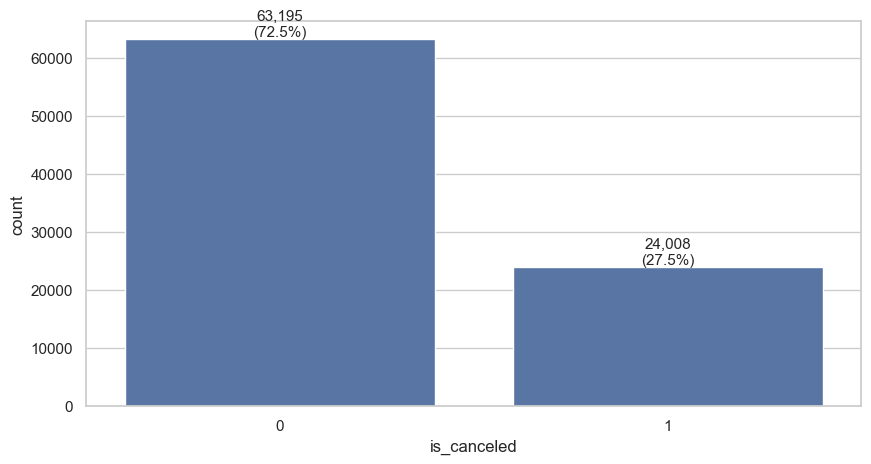

In [31]:
counts = df["is_canceled"].value_counts()
percentages = df["is_canceled"].value_counts(normalize=True) * 100

ax = sns.countplot(
    data=df,
    x="is_canceled",
    color=PRIMARY_COLOR
)

for i, p in enumerate(ax.patches):
    ax.annotate(
        f"{counts.iloc[i]:,}\n({percentages.iloc[i]:.1f}%)",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11
    )

📝 Observation

Approximately 72.5% of hotel bookings were completed successfully without cancellation.
Around 27.5% of bookings were canceled before the arrival date.
The target variable is moderately imbalanced, with non-canceled bookings representing the majority of observations.

💼 Business Insight

Nearly one out of every four bookings is canceled, representing a significant source of potential revenue loss for hotels. Understanding the factors associated with cancellations will help improve demand forecasting, optimize pricing strategies, and reduce the financial impact of booking cancellations.

### 5.2.2 Numerical Features

#### Lead Time

Objective :
analyze the distribution of Lead Time and identify potential outliers.

Business Value :
understanding how early customers make reservations helps hotels improve demand forecasting and booking management.

In [32]:
# Display basic statistics for Lead Time

print("📌 Basic Statistics for Lead Time")

display(df["lead_time"].describe().to_frame().T)

📌 Basic Statistics for Lead Time


,count,mean,std,min,25%,50%,75%,max
lead_time,87203.0,79.990081,86.062432,0.0,11.0,49.0,125.0,737.0


In [33]:
# Calculate the mean and median of Lead Time

mean = df["lead_time"].mean()
median = df["lead_time"].median()

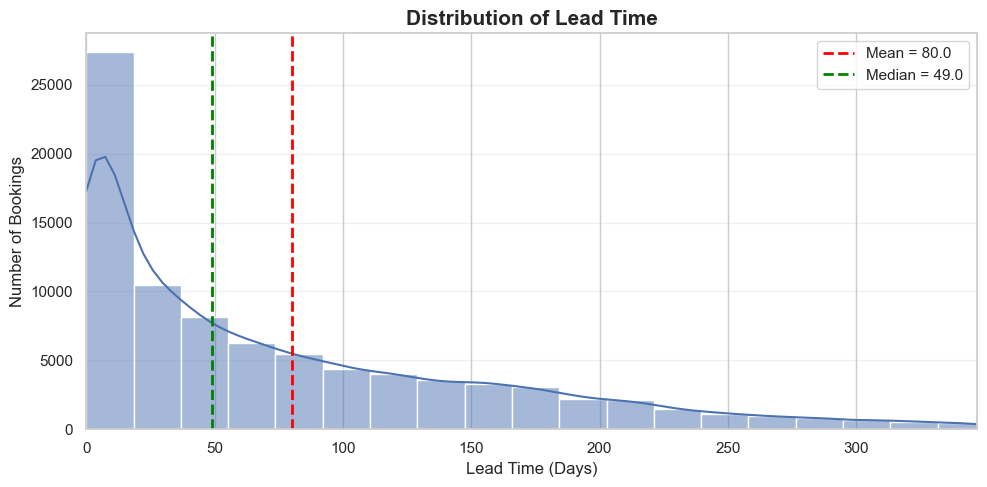

In [34]:
# Visualize the distribution of Lead Time

plt.figure(figsize=(10,5))

sns.histplot(
    df["lead_time"],
    bins=40,
    kde=True,
    color=PRIMARY_COLOR,
    edgecolor="white"
)

plt.axvline(
    mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean:.1f}"
)

plt.axvline(
    median,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median:.1f}"
)

plt.xlim(0, df["lead_time"].quantile(0.99))

plt.title("Distribution of Lead Time", fontsize=15, weight="bold")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Number of Bookings")

plt.legend()

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

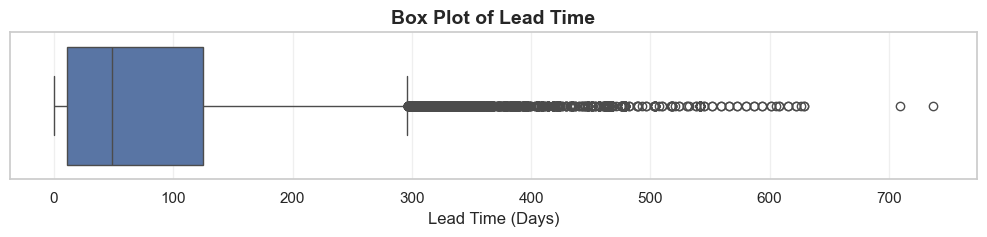

In [35]:
# Visualize the spread of Lead Time values

plt.figure(figsize=(10,2.5))

sns.boxplot(
    x=df["lead_time"],
    color=PRIMARY_COLOR
)

plt.title("Box Plot of Lead Time", fontsize=14, weight="bold")
plt.xlabel("Lead Time (Days)")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

In [36]:
# Detect outliers using the IQR method

print("🔽 Lowest 5 Values")

display(df["lead_time"].sort_values().head())

print("🔼 Highest 5 Values")

display(df["lead_time"].sort_values(ascending=False).head())

Q1 = df["lead_time"].quantile(0.25)
Q3 = df["lead_time"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["lead_time"] < lower_bound) |
    (df["lead_time"] > upper_bound)
]

print(f"🚨 Number of Outliers: {len(outliers)}")

🔽 Lowest 5 Values


14565    0
15238    0
67489    0
67476    0
17204    0
Name: lead_time, dtype: int64

🔼 Highest 5 Values


1        737
3371     709
47709    629
47704    629
44675    626
Name: lead_time, dtype: int64

🚨 Number of Outliers: 2394


📝 Observation

The Lead Time ranges from 0 to 737 days, with an average of approximately 80 days.
The distribution is positively (right) skewed, indicating that most customers book their stays within a relatively short period before arrival.
The box plot reveals 2,394 outliers, representing bookings made significantly earlier than the majority of reservations.
The median (49 days) is lower than the mean (80 days), which further confirms the right-skewed distribution.

💼 Business Insight

Most guests book their stays within a short period before arrival, while a smaller group books several months in advance. Since Lead Time shows considerable variation, it is expected to play an important role in predicting booking cancellations and understanding customer booking behavior.

#### Average Daily Rate (ADR)

Objective :
analyze the distribution of the Average Daily Rate (ADR) and identify unusual pricing values.

Business Value :
understanding room pricing helps hotels optimize revenue management and pricing strategies.

In [37]:
# Display basic statistics for ADR

print("📌 Basic Statistics for ADR")

display(df["adr"].describe().to_frame().T)

📌 Basic Statistics for ADR


,count,mean,std,min,25%,50%,75%,max
adr,87203.0,106.529087,54.880407,0.0,72.25,98.25,134.1,5400.0


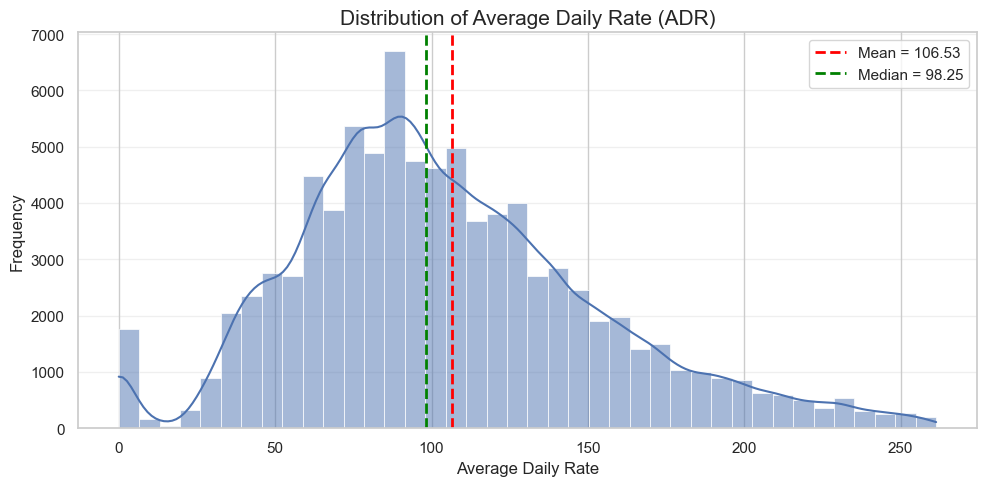

In [38]:
# Plot the distribution of ADR
# Mean and median are added to identify the distribution shape

plt.figure(figsize=(10,5))

plot_data = df[df["adr"] <= df["adr"].quantile(0.99)]

sns.histplot(
    data=plot_data,
    x="adr",
    bins=40,
    kde=True,
    color=PRIMARY_COLOR,
    edgecolor="white",
    linewidth=0.5
)

plt.axvline(
    df["adr"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {df['adr'].mean():.2f}"
)

plt.axvline(
    df["adr"].median(),
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Median = {df['adr'].median():.2f}"
)

plt.title("Distribution of Average Daily Rate (ADR)")
plt.xlabel("Average Daily Rate")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

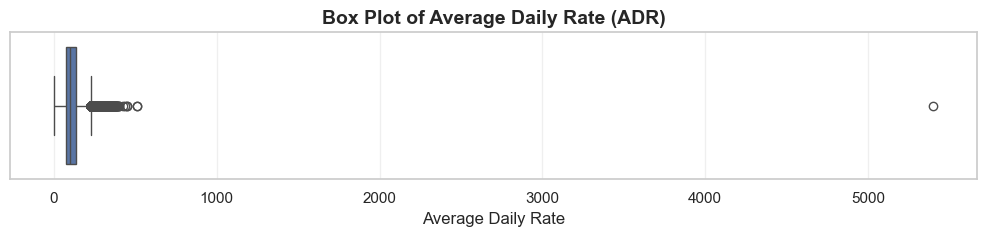

In [39]:
# Visualize the spread of ADR values

plt.figure(figsize=(10,2.5))

sns.boxplot(
    x=df["adr"],
    color=PRIMARY_COLOR
)

plt.title("Box Plot of Average Daily Rate (ADR)", fontsize=14, weight="bold")
plt.xlabel("Average Daily Rate")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

In [40]:
# Identify outliers using the IQR method

print("🔽 Lowest 5 Values")
display(df["adr"].sort_values().head())

print("🔼 Highest 5 Values")
display(df["adr"].sort_values(ascending=False).head())

Q1 = df["adr"].quantile(0.25)
Q3 = df["adr"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = df[
    (df["adr"] < lower_bound) |
    (df["adr"] > upper_bound)
]

print(f"🚨 Number of Outliers: {len(outliers)}")

🔽 Lowest 5 Values


0        0.0
24897    0.0
3292     0.0
24918    0.0
3277     0.0
Name: adr, dtype: float64

🔼 Highest 5 Values


38701    5400.0
80551     510.0
11650     508.0
74318     451.5
9976      450.0
Name: adr, dtype: float64

🚨 Number of Outliers: 2506


📝 Observation

The Average Daily Rate (ADR) ranges from 0 to 5400, with an average of approximately 106.53.
The distribution is highly right-skewed, as most bookings have ADR values below 200, while a small number of bookings have exceptionally high rates.
The mean (106.53) is higher than the median (98.25), confirming the presence of a positively skewed distribution.
The box plot identifies 2,506 outliers, including an extreme value of 5400, which is considerably higher than the rest of the observations.

💼 Business Insight

Most hotel bookings fall within a typical price range, while only a few premium or unusual bookings have exceptionally high ADR values. Since room price can influence customer booking behavior and cancellation decisions, ADR is expected to be an important feature in predicting booking cancellations.

#### Weekend Stay Nights

Objective : analyze the distribution of weekend stay nights to understand how long guests typically stay during weekends.

Business Value : weekend stay duration provides insights into customer travel behavior and helps hotels optimize weekend occupancy, pricing, and resource planning.

In [41]:
# Display basic statistics for Weekend Stay Nights

print("📌 Basic Statistics for Weekend Stay Nights")

display(df["stays_in_weekend_nights"].describe().to_frame().T)

📌 Basic Statistics for Weekend Stay Nights


,count,mean,std,min,25%,50%,75%,max
stays_in_weekend_nights,87203.0,1.004759,1.027416,0.0,0.0,1.0,2.0,19.0


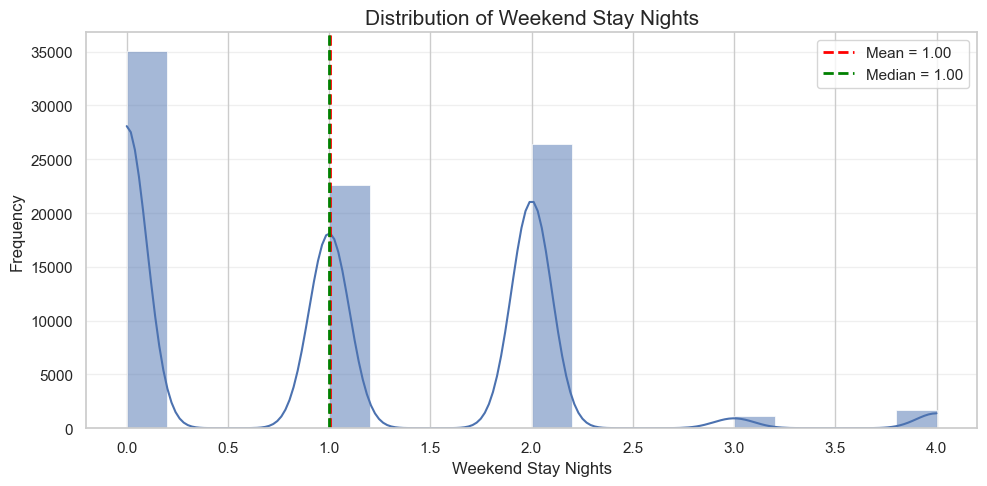

In [42]:
# Plot the distribution of Weekend Stay Nights
# Mean and median are added to identify the distribution shape

plt.figure(figsize=(10,5))

plot_data = df[
    df["stays_in_weekend_nights"] <=
    df["stays_in_weekend_nights"].quantile(0.99)
]

sns.histplot(
    data=plot_data,
    x="stays_in_weekend_nights",
    bins=20,
    kde=True,
    color=PRIMARY_COLOR,
    edgecolor="white",
    linewidth=0.5
)

plt.axvline(
    df["stays_in_weekend_nights"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {df['stays_in_weekend_nights'].mean():.2f}"
)

plt.axvline(
    df["stays_in_weekend_nights"].median(),
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Median = {df['stays_in_weekend_nights'].median():.2f}"
)

plt.title("Distribution of Weekend Stay Nights")
plt.xlabel("Weekend Stay Nights")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

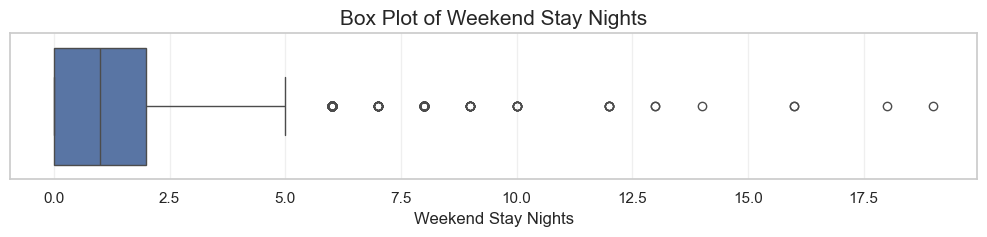

In [43]:
# Plot the box plot of Weekend Stay Nights

plt.figure(figsize=(10,2.5))

sns.boxplot(
    x=df["stays_in_weekend_nights"],
    color=PRIMARY_COLOR
)

plt.title("Box Plot of Weekend Stay Nights")
plt.xlabel("Weekend Stay Nights")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

In [44]:
# Identify outliers using the IQR method

print("🔽 Lowest 5 Values")
display(df["stays_in_weekend_nights"].sort_values().head())

print("🔼 Highest 5 Values")
display(df["stays_in_weekend_nights"].sort_values(ascending=False).head())

Q1 = df["stays_in_weekend_nights"].quantile(0.25)
Q3 = df["stays_in_weekend_nights"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = df[
    (df["stays_in_weekend_nights"] < lower_bound) |
    (df["stays_in_weekend_nights"] > upper_bound)
]

print(f"🚨 Number of Outliers: {len(outliers)}")

🔽 Lowest 5 Values


0        0
29134    0
29135    0
29136    0
29137    0
Name: stays_in_weekend_nights, dtype: int64

🔼 Highest 5 Values


10818    19
10817    18
7393     16
28298    16
41825    14
Name: stays_in_weekend_nights, dtype: int64

🚨 Number of Outliers: 213


📝 Observation

Weekend Stay Nights range from 0 to 19 nights, with an average of approximately 1 night.
Both the mean and median are equal to 1, indicating that the typical guest spends one weekend night at the hotel.
Most bookings include 0 to 2 weekend nights, while longer weekend stays are relatively uncommon.
The box plot identifies 213 potential outliers, representing bookings with unusually long weekend stays.

💼 Business Insight

The majority of guests spend only one or two weekend nights, suggesting that short leisure trips are the most common booking pattern. Extended weekend stays are rare and may correspond to vacation packages or long holiday periods. Therefore, Weekend Stay Nights may contribute to understanding customer behavior and improving cancellation prediction models.

#### Week Stay Nights

Objective : analyze the distribution of weekday stay nights to understand how long guests typically stay during weekdays.

Business Value : the number of weekday nights helps hotels understand guest stay patterns, optimize room occupancy, and improve operational planning during the week.

In [45]:
# Display basic statistics for Week Stay Nights

print("📌 Basic Statistics for Week Stay Nights")

display(df["stays_in_week_nights"].describe().to_frame().T)

📌 Basic Statistics for Week Stay Nights


,count,mean,std,min,25%,50%,75%,max
stays_in_week_nights,87203.0,2.62429,2.039915,0.0,1.0,2.0,4.0,50.0


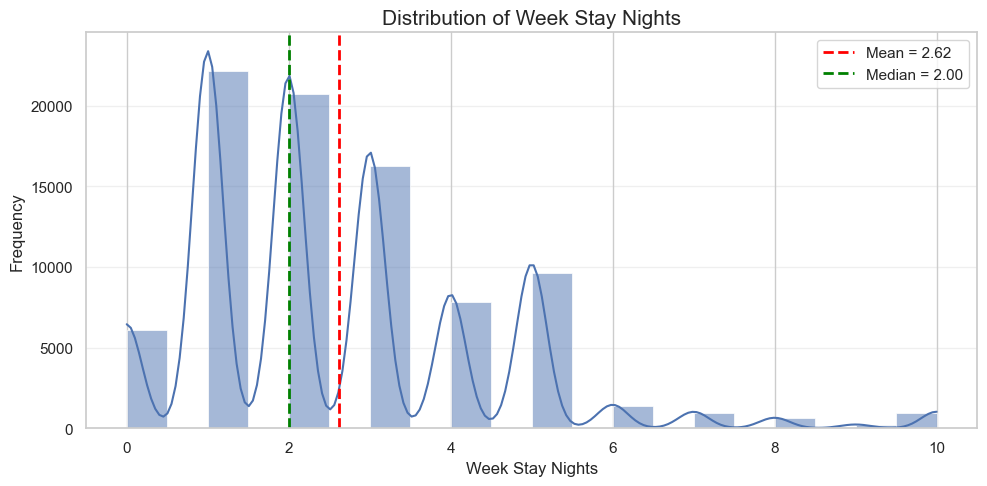

In [46]:
# Plot the distribution of Week Stay Nights
# Mean and median are added to identify the distribution shape

plt.figure(figsize=(10,5))

plot_data = df[
    df["stays_in_week_nights"] <=
    df["stays_in_week_nights"].quantile(0.99)
]

sns.histplot(
    data=plot_data,
    x="stays_in_week_nights",
    bins=20,
    kde=True,
    color=PRIMARY_COLOR,
    edgecolor="white",
    linewidth=0.5
)

plt.axvline(
    df["stays_in_week_nights"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {df['stays_in_week_nights'].mean():.2f}"
)

plt.axvline(
    df["stays_in_week_nights"].median(),
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Median = {df['stays_in_week_nights'].median():.2f}"
)

plt.title("Distribution of Week Stay Nights")
plt.xlabel("Week Stay Nights")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

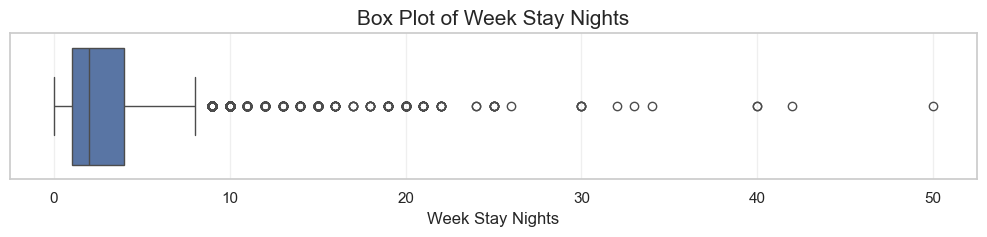

In [47]:
# Plot the box plot of Week Stay Nights

plt.figure(figsize=(10,2.5))

sns.boxplot(
    x=df["stays_in_week_nights"],
    color=PRIMARY_COLOR
)

plt.title("Box Plot of Week Stay Nights")
plt.xlabel("Week Stay Nights")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

In [48]:
# Identify outliers using the IQR method

print("🔽 Lowest 5 Values")
display(df["stays_in_week_nights"].sort_values().head())

print("🔼 Highest 5 Values")
display(df["stays_in_week_nights"].sort_values(ascending=False).head())

Q1 = df["stays_in_week_nights"].quantile(0.25)
Q3 = df["stays_in_week_nights"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = df[
    (df["stays_in_week_nights"] < lower_bound) |
    (df["stays_in_week_nights"] > upper_bound)
]

print(f"🚨 Number of Outliers: {len(outliers)}")

🔽 Lowest 5 Values


0        0
23731    0
60277    0
23737    0
60275    0
Name: stays_in_week_nights, dtype: int64

🔼 Highest 5 Values


10818    50
10817    42
7393     40
28298    40
41825    34
Name: stays_in_week_nights, dtype: int64

🚨 Number of Outliers: 1514


📝 Observation

Week Stay Nights range from 0 to 50 nights, with an average of approximately 2.62 nights.
Most guests stay between 1 and 4 week nights, with the median equal to 2 nights.
The distribution is positively skewed, as indicated by the mean being higher than the median.
The box plot identifies 1,514 potential outliers, representing bookings with unusually long weekday stays.

💼 Business Insight

Most hotel guests spend only a few nights during weekdays, while extended weekday stays are relatively uncommon. Although long stays are rare, they may represent business travelers, long-term guests, or special reservations. Therefore, Week Stay Nights may provide useful information when analyzing customer booking behavior and predicting cancellations.

#### Booking Changes

Objective : analyze the distribution of booking modifications made before the guest's arrival.

Business Value : booking changes reflect customer behavior before check-in. Guests who modify their reservations may have different cancellation patterns compared to those who never change their bookings.

In [49]:
# Display basic statistics for Booking Changes

print("📌 Basic Statistics for Booking Changes")

display(df["booking_changes"].describe().to_frame().T)

📌 Basic Statistics for Booking Changes


,count,mean,std,min,25%,50%,75%,max
booking_changes,87203.0,0.268546,0.7107,0.0,0.0,0.0,0.0,18.0


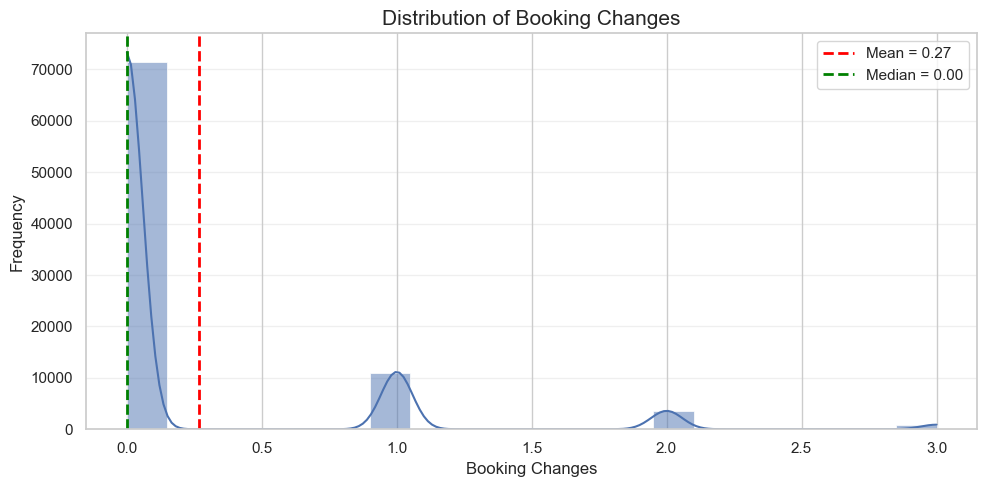

In [50]:
# Plot the distribution of Booking Changes
# Mean and median are added to identify the distribution shape

plt.figure(figsize=(10,5))

plot_data = df[
    df["booking_changes"] <=
    df["booking_changes"].quantile(0.99)
]

sns.histplot(
    data=plot_data,
    x="booking_changes",
    bins=20,
    kde=True,
    color=PRIMARY_COLOR,
    edgecolor="white",
    linewidth=0.5
)

plt.axvline(
    df["booking_changes"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {df['booking_changes'].mean():.2f}"
)

plt.axvline(
    df["booking_changes"].median(),
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Median = {df['booking_changes'].median():.2f}"
)

plt.title("Distribution of Booking Changes")
plt.xlabel("Booking Changes")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

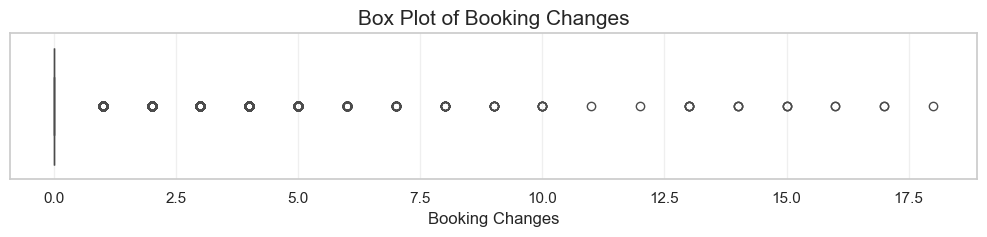

In [51]:
# Plot the box plot of Booking Changes

plt.figure(figsize=(10,2.5))

sns.boxplot(
    x=df["booking_changes"],
    color=PRIMARY_COLOR
)

plt.title("Box Plot of Booking Changes")
plt.xlabel("Booking Changes")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

In [52]:
# Identify outliers using the IQR method

print("🔽 Lowest 5 Values")
display(df["booking_changes"].sort_values().head())

print("🔼 Highest 5 Values")
display(df["booking_changes"].sort_values(ascending=False).head())

Q1 = df["booking_changes"].quantile(0.25)
Q3 = df["booking_changes"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = df[
    (df["booking_changes"] < lower_bound) |
    (df["booking_changes"] > upper_bound)
]

print(f"🚨 Number of Outliers: {len(outliers)}")


🔽 Lowest 5 Values


43601    0
54557    0
54556    0
54555    0
54553    0
Name: booking_changes, dtype: int64

🔼 Highest 5 Values


80783    18
40515    17
1570     17
80790    16
6827     16
Name: booking_changes, dtype: int64

🚨 Number of Outliers: 15803


###### Note : The large number of outliers is expected because most bookings have zero changes, resulting in an IQR of zero. Consequently, any booking with one or more changes is identified as a potential outlier by the IQR method.


📝 Observation

Booking Changes range from 0 to 18 changes, with an average of approximately 0.27 changes.
The median is 0, indicating that more than half of the bookings were never modified after being made.
The distribution is highly right-skewed, as most bookings have no changes, while only a small proportion have multiple modifications.
Using the IQR method, 15,803 potential outliers were detected, representing bookings with one or more changes beyond the typical range.

💼 Business Insight

Most customers do not modify their reservations after booking, suggesting that reservation details usually remain unchanged. However, a smaller group of customers makes multiple booking changes, which may reflect uncertainty or changing travel plans. Therefore, Booking Changes may provide valuable information for understanding customer behavior and improving booking cancellation prediction.

#### Days in Waiting List

Objective : analyze the number of waiting days before booking confirmation.

Business Value : waiting time may influence customer satisfaction and booking cancellations, making it a potentially useful feature for predictive analysis.

In [53]:
# Display basic statistics for Days in Waiting List

print("📌 Basic Statistics for Days in Waiting List")

display(df["days_in_waiting_list"].describe().to_frame().T)

📌 Basic Statistics for Days in Waiting List


,count,mean,std,min,25%,50%,75%,max
days_in_waiting_list,87203.0,0.746522,10.00254,0.0,0.0,0.0,0.0,391.0


In [54]:
# Display the most frequent waiting days

print("📌 Top 10 Waiting Days")

display(df["days_in_waiting_list"].value_counts().head(10))

📌 Top 10 Waiting Days


days_in_waiting_list
0      86348
63        53
87        25
44        23
15        22
48        21
58        21
38        19
122       19
77        17
Name: count, dtype: int64

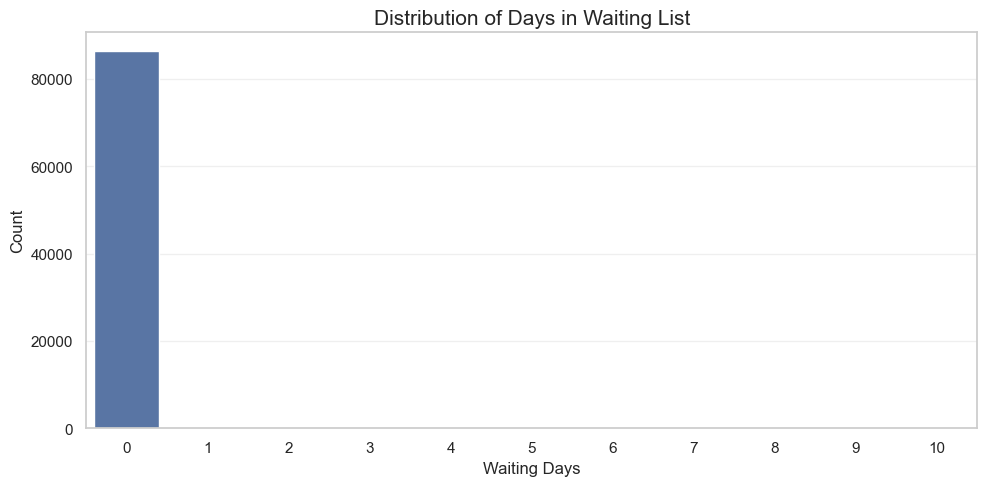

In [55]:
# Plot the distribution of Days in Waiting List

plt.figure(figsize=(10,5))

plot_data = df[df["days_in_waiting_list"] <= 10]

sns.countplot(
    data=plot_data,
    x="days_in_waiting_list",
    color=PRIMARY_COLOR
)

plt.title("Distribution of Days in Waiting List")
plt.xlabel("Waiting Days")
plt.ylabel("Count")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [56]:
# Identify outliers using the IQR method

print("🔽 Lowest 5 Values")
display(df["days_in_waiting_list"].sort_values().head())

print("🔼 Highest 5 Values")
display(df["days_in_waiting_list"].sort_values(ascending=False).head())

Q1 = df["days_in_waiting_list"].quantile(0.25)
Q3 = df["days_in_waiting_list"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = df[
    (df["days_in_waiting_list"] < lower_bound) |
    (df["days_in_waiting_list"] > upper_bound)
]

print(f"🚨 Number of Outliers: {len(outliers)}")

🔽 Lowest 5 Values


0        0
58103    0
58102    0
58101    0
58100    0
Name: days_in_waiting_list, dtype: int64

🔼 Highest 5 Values


43913    391
44246    391
44424    391
44415    391
44249    391
Name: days_in_waiting_list, dtype: int64

🚨 Number of Outliers: 855


📝 Observation

Days in Waiting List range from 0 to 391 days, with an average of approximately 0.75 days.
The median is 0, indicating that the vast majority of bookings were confirmed immediately without any waiting period.
More than 99% of bookings have 0 waiting days, resulting in an extremely right-skewed distribution.
Using the IQR method, 855 potential outliers were detected, representing bookings with unusually long waiting periods.

💼 Business Insight

Most hotel bookings are confirmed immediately, suggesting that waiting lists are uncommon in normal booking operations. Only a small number of reservations experience long waiting periods, which may occur during peak demand or when room availability is limited. Therefore, Days in Waiting List may still provide useful information for understanding booking behavior and predicting cancellations, despite its highly imbalanced distribution.

### 5.2.3 Count-Based Features


#### adults


Objective : analyze the distribution of the number of adults per booking.

Business Value : understanding the number of adults per reservation helps hotels optimize room allocation, capacity planning, and customer segmentation.

In [57]:
# Display basic statistics for Adults

print("📌 Basic Statistics for Adults")

display(df["adults"].describe().to_frame().T)

📌 Basic Statistics for Adults


,count,mean,std,min,25%,50%,75%,max
adults,87203.0,1.879522,0.621698,0.0,2.0,2.0,2.0,55.0


In [58]:
# Display the frequency of each number of adults

print("📌 Value Counts for Adults")

display(df["adults"].value_counts().sort_index())

📌 Value Counts for Adults


adults
0       219
1     16486
2     64487
3      5935
4        60
5         2
6         1
10        1
20        2
26        5
27        2
40        1
50        1
55        1
Name: count, dtype: int64

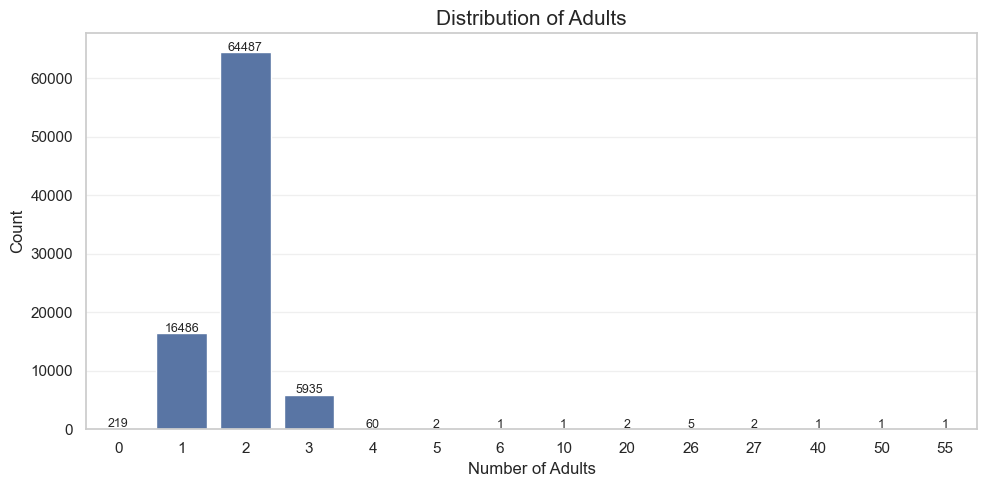

In [59]:
# Plot the distribution of Adults

plt.figure(figsize=(10,5))

counts = df["adults"].value_counts().sort_index()

sns.barplot(
    x=counts.index,
    y=counts.values,
    color=PRIMARY_COLOR
)

for i, value in enumerate(counts.values):
    plt.text(
        i,
        value + 200,
        f"{value}",
        ha="center",
        fontsize=9
    )

plt.title("Distribution of Adults")
plt.xlabel("Number of Adults")
plt.ylabel("Count")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [60]:
# Identify outliers using the IQR method

print("🔽 Lowest 5 Values")
display(df["adults"].sort_values().head())

print("🔼 Highest 5 Values")
display(df["adults"].sort_values(ascending=False).head())

Q1 = df["adults"].quantile(0.25)
Q3 = df["adults"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = df[
    (df["adults"] < lower_bound) |
    (df["adults"] > upper_bound)
]

print(f"🚨 Number of Outliers: {len(outliers)}")

🔽 Lowest 5 Values


78902    0
36919    0
86214    0
48109    0
47727    0
Name: adults, dtype: int64

🔼 Highest 5 Values


2053    55
1558    50
1455    40
1816    27
1859    27
Name: adults, dtype: int64

🚨 Number of Outliers: 22716


📝 Observation

The number of adults ranges from 0 to 55, with an average of approximately 1.88 adults per booking.
The median is 2, indicating that a typical booking includes two adults.
Most reservations are made for 2 adults (64,487 bookings), followed by 1 adult (16,486 bookings) and 3 adults (5,935 bookings).
Bookings with 4 or more adults are very rare and represent only a small fraction of the dataset.
Using the IQR method, 22,716 potential outliers were detected. This large number is expected because the IQR equals zero (Q1 = Median = Q3 = 2), causing bookings with values outside the typical range to be flagged as potential outliers.

💼 Business Insight

Most hotel reservations are made for one or two adults, indicating that couples and individual travelers represent the majority of customers. Larger groups are relatively uncommon and may correspond to family trips, group bookings, or exceptional cases. Therefore, the number of adults is likely to be a useful feature for customer segmentation and booking cancellation prediction.

#### Children

Objective : analyze the distribution of the number of children per booking.

Business Value : understanding the number of children helps hotels identify family travel patterns and optimize family-oriented services.

In [61]:
# Display basic statistics for Children

print("📌 Basic Statistics for Children")

display(df["children"].describe().to_frame().T)

📌 Basic Statistics for Children


,count,mean,std,min,25%,50%,75%,max
children,87203.0,0.13894,0.456329,0.0,0.0,0.0,0.0,10.0


In [62]:
# Display the frequency of each number of children

print("📌 Value Counts for Children")

display(df["children"].value_counts().sort_index())

📌 Value Counts for Children


children
0     78839
1      4695
2      3593
3        75
10        1
Name: count, dtype: int64

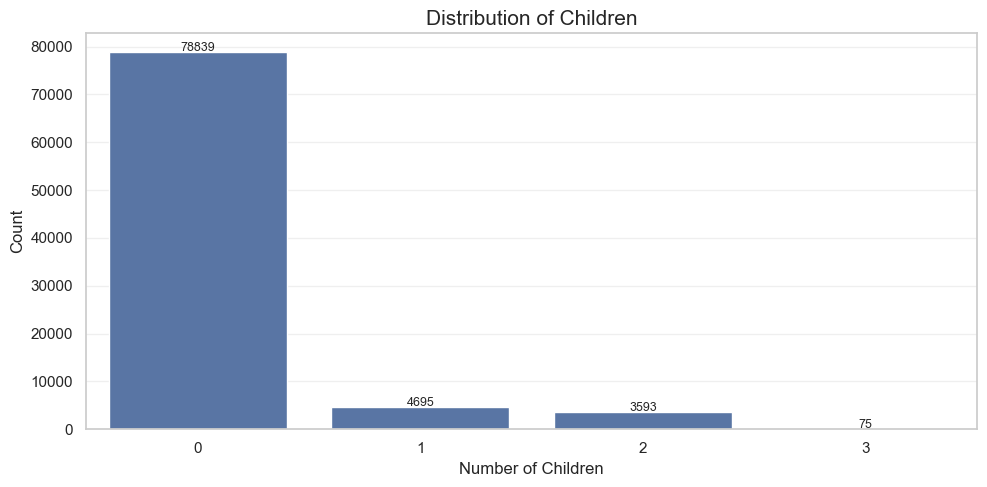

In [63]:
# Plot the distribution of Children

plt.figure(figsize=(10,5))

counts = (
    df["children"]
    .value_counts()
    .sort_index()
    .loc[0:3]
)

sns.barplot(
    x=counts.index,
    y=counts.values,
    color=PRIMARY_COLOR
)

for i, value in enumerate(counts.values):
    plt.text(
        i,
        value + 200,
        f"{value}",
        ha="center",
        fontsize=9
    )

plt.title("Distribution of Children")
plt.xlabel("Number of Children")
plt.ylabel("Count")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [64]:
# Identify outliers using the IQR method

print("🔽 Lowest 5 Values")
display(df["children"].sort_values().head())

print("🔼 Highest 5 Values")
display(df["children"].sort_values(ascending=False).head())

Q1 = df["children"].quantile(0.25)
Q3 = df["children"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = df[
    (df["children"] < lower_bound) |
    (df["children"] > upper_bound)
]

print(f"🚨 Number of Outliers: {len(outliers)}")

🔽 Lowest 5 Values


0        0
56716    0
56715    0
56714    0
56713    0
Name: children, dtype: int32

🔼 Highest 5 Values


320      10
69987     3
84223     3
41948     3
41946     3
Name: children, dtype: int32

🚨 Number of Outliers: 8364


📝 Observation

The number of children ranges from 0 to 10, with an average of approximately 0.14 children per booking.
The median is 0, indicating that most hotel bookings do not include children.
Approximately 90% of bookings have no children (78,839 bookings), while 4,695 bookings include one child and 3,593 bookings include two children.
Bookings with three or more children are extremely rare, with only 75 bookings having three children and a single booking recording ten children.
Using the IQR method, 8,364 potential outliers were detected. Since the first and third quartiles are both zero (Q1 = Q3 = 0), any booking with one or more children is identified as a potential outlier by the IQR rule.

💼 Business Insight

Most hotel reservations are made without children, suggesting that the majority of guests are couples, solo travelers, or adult groups. Family bookings with children represent a smaller but meaningful customer segment and may exhibit different booking and cancellation behaviors. Therefore, the number of children is expected to be a useful feature for customer segmentation and cancellation prediction.


#### Babies

Objective : analyze the distribution of the number of babies per booking.

Business Value : understanding the number of babies helps hotels estimate the demand for baby-friendly facilities such as baby cots and family services.

In [65]:
# Display basic statistics for Babies

print("📌 Basic Statistics for Babies")

display(df["babies"].describe().to_frame().T)

📌 Basic Statistics for Babies


,count,mean,std,min,25%,50%,75%,max
babies,87203.0,0.010848,0.113721,0.0,0.0,0.0,0.0,10.0


In [66]:
# Display the frequency of each Babies value

print("📌 Value Counts for Babies")

display(df["babies"].value_counts().sort_index())

📌 Value Counts for Babies


babies
0     86289
1       897
2        15
9         1
10        1
Name: count, dtype: int64

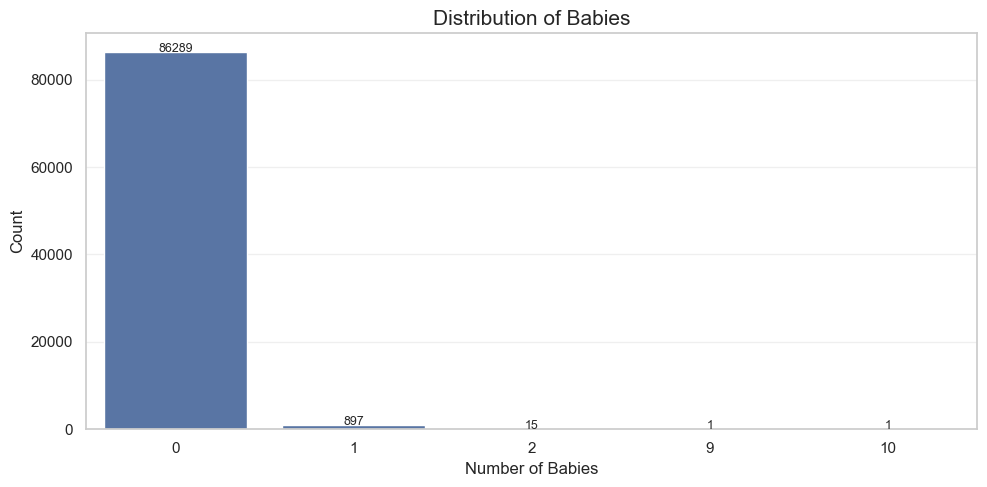

In [67]:
# Plot the distribution of Babies

plt.figure(figsize=(10,5))

counts = (
    df["babies"]
    .value_counts()
    .sort_index()
)

sns.barplot(
    x=counts.index,
    y=counts.values,
    color=PRIMARY_COLOR
)

for i, value in enumerate(counts.values):
    plt.text(
        i,
        value + 50,
        f"{value}",
        ha="center",
        fontsize=9
    )

plt.title("Distribution of Babies")
plt.xlabel("Number of Babies")
plt.ylabel("Count")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [68]:
# Identify outliers using the IQR method

print("🔽 Lowest 5 Values")
display(df["babies"].sort_values().head())

print("🔼 Highest 5 Values")
display(df["babies"].sort_values(ascending=False).head())

Q1 = df["babies"].quantile(0.25)
Q3 = df["babies"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = df[
    (df["babies"] < lower_bound) |
    (df["babies"] > upper_bound)
]

print(f"🚨 Number of Outliers: {len(outliers)}")

🔽 Lowest 5 Values


0        0
58014    0
58013    0
58012    0
58011    0
Name: babies, dtype: int64

🔼 Highest 5 Values


37252    10
54417     9
12952     2
24821     2
11332     2
Name: babies, dtype: int64

🚨 Number of Outliers: 914


📝 Observation

The number of babies ranges from 0 to 10, with an average of approximately 0.01 babies per booking.
The median is 0, indicating that almost all hotel bookings do not include babies.
The vast majority of reservations (86,289 bookings) have no babies, while 897 bookings include one baby and only 15 bookings include two babies.
Bookings with 9 or 10 babies are extremely rare and likely represent exceptional cases or possible data entry errors.
Using the IQR method, 914 potential outliers were detected. Since both the first and third quartiles are zero (Q1 = Q3 = 0), any booking with one or more babies is classified as a potential outlier.

💼 Business Insight

Most hotel reservations are made without babies, indicating that guests traveling with infants represent only a very small portion of customers. Although this feature is highly imbalanced, it can still help identify family bookings and may provide additional value when predicting booking cancellations or customer booking patterns.

#### Previous Cancellations

Objective : analyze the distribution of the number of previous canceled bookings made by each customer.

Business Value : customers with a history of previous cancellations may be more likely to cancel future bookings. This feature can provide valuable insights into customer behavior and improve cancellation prediction.

In [69]:
# Display basic statistics for Previous Cancellations

print("📌 Basic Statistics for Previous Cancellations")

display(df["previous_cancellations"].describe().to_frame().T)

📌 Basic Statistics for Previous Cancellations


,count,mean,std,min,25%,50%,75%,max
previous_cancellations,87203.0,0.030412,0.369401,0.0,0.0,0.0,0.0,26.0


In [70]:
# Display the frequency of each Previous Cancellations value

print("📌 Value Counts for Previous Cancellations")

display(df["previous_cancellations"].value_counts().sort_index())

📌 Value Counts for Previous Cancellations


previous_cancellations
0     85522
1      1405
2       110
3        61
4        30
5        19
6        17
11       27
13        4
14        1
19        1
21        1
24        2
25        2
26        1
Name: count, dtype: int64

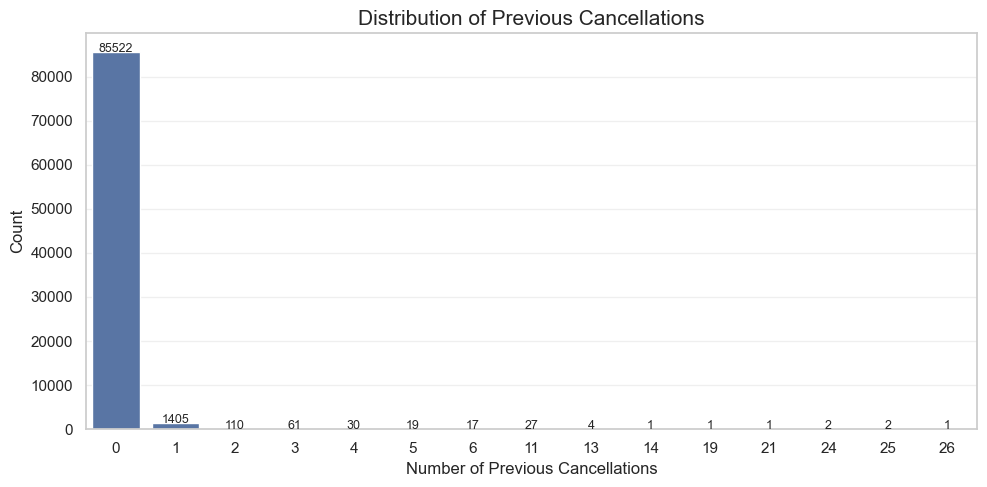

In [71]:
# Plot the distribution of Previous Cancellations

plt.figure(figsize=(10,5))

counts = (
    df["previous_cancellations"]
    .value_counts()
    .sort_index()
)

sns.barplot(
    x=counts.index,
    y=counts.values,
    color=PRIMARY_COLOR
)

for i, value in enumerate(counts.values):
    plt.text(
        i,
        value + 50,
        f"{value}",
        ha="center",
        fontsize=9
    )

plt.title("Distribution of Previous Cancellations")
plt.xlabel("Number of Previous Cancellations")
plt.ylabel("Count")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [72]:
# Identify outliers using the IQR method

print("🔽 Lowest 5 Values")
display(df["previous_cancellations"].sort_values().head())

print("🔼 Highest 5 Values")
display(df["previous_cancellations"].sort_values(ascending=False).head())

Q1 = df["previous_cancellations"].quantile(0.25)
Q3 = df["previous_cancellations"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = df[
    (df["previous_cancellations"] < lower_bound) |
    (df["previous_cancellations"] > upper_bound)
]

print(f"🚨 Number of Outliers: {len(outliers)}")

🔽 Lowest 5 Values


0        0
58366    0
58365    0
58364    0
58363    0
Name: previous_cancellations, dtype: int64

🔼 Highest 5 Values


11464    26
11488    25
11489    25
11583    24
11693    24
Name: previous_cancellations, dtype: int64

🚨 Number of Outliers: 1681


📝 Observation

The number of previous cancellations ranges from 0 to 26, with an average of approximately 0.03 cancellations per customer.
The median is 0, indicating that almost all customers have no history of previous cancellations.
The distribution is highly right-skewed, with 85,522 bookings having zero previous cancellations, while only a small number of customers have one or more previous cancellations.
A few customers have a relatively high cancellation history, with the maximum reaching 26 previous cancellations, although these cases are extremely rare.
Using the IQR method, all bookings with one or more previous cancellations are identified as potential outliers because both the first and third quartiles are zero (Q1 = Q3 = 0).

💼 Business Insight

The vast majority of customers have no previous cancellation history, while only a small group has canceled bookings in the past. Despite its highly imbalanced distribution, this feature is expected to be a strong predictor of future booking cancellations, as customers with previous cancellations may exhibit less stable booking behavior.

#### Previous Bookings Not Canceled

Objective : analyze the distribution of the number of previous bookings that were successfully completed without cancellation.

Business Value : a customer's successful booking history may reflect loyalty and booking reliability. Customers with many completed bookings may be less likely to cancel future reservations.

In [73]:
# Display basic statistics for Previous Bookings Not Canceled

print("📌 Basic Statistics for Previous Bookings Not Canceled")

display(df["previous_bookings_not_canceled"].describe().to_frame().T)

📌 Basic Statistics for Previous Bookings Not Canceled


,count,mean,std,min,25%,50%,75%,max
previous_bookings_not_canceled,87203.0,0.184088,1.733288,0.0,0.0,0.0,0.0,72.0


In [74]:
# Display the frequency of each Previous Bookings Not Canceled value

print("📌 Value Counts for Previous Bookings Not Canceled")

display(df["previous_bookings_not_canceled"].value_counts().sort_index())

📌 Value Counts for Previous Bookings Not Canceled


previous_bookings_not_canceled
0     83666
1      1478
2       579
3       331
4       228
      ...  
68        1
69        1
70        1
71        1
72        1
Name: count, Length: 73, dtype: int64

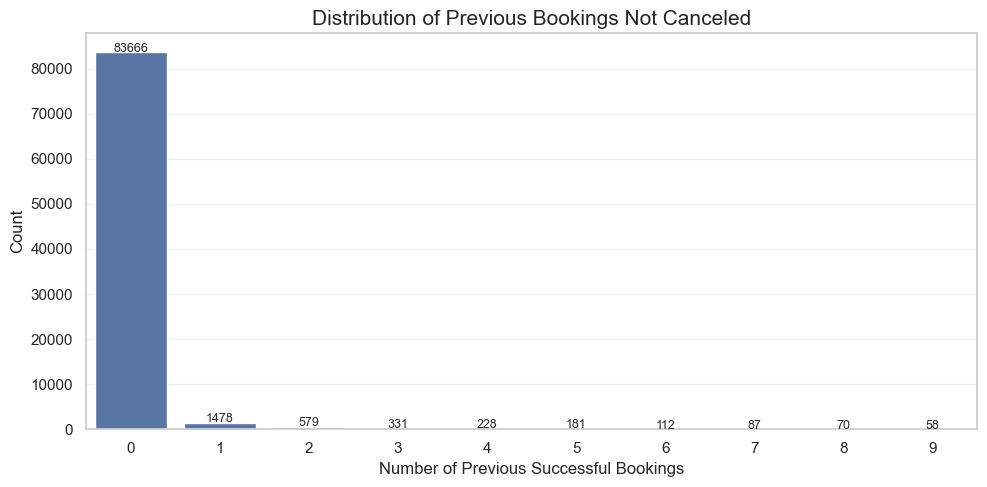

In [75]:
# Plot the distribution of Previous Bookings Not Canceled

plt.figure(figsize=(10,5))

counts = (
    df["previous_bookings_not_canceled"]
    .value_counts()
    .sort_index()
    .head(10)
)

sns.barplot(
    x=counts.index,
    y=counts.values,
    color=PRIMARY_COLOR
)

for i, value in enumerate(counts.values):
    plt.text(
        i,
        value + 50,
        f"{value}",
        ha="center",
        fontsize=9
    )

plt.title("Distribution of Previous Bookings Not Canceled")
plt.xlabel("Number of Previous Successful Bookings")
plt.ylabel("Count")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [76]:
# Identify outliers using the IQR method

print("🔽 Lowest 5 Values")
display(df["previous_bookings_not_canceled"].sort_values().head())

print("🔼 Highest 5 Values")
display(df["previous_bookings_not_canceled"].sort_values(ascending=False).head())

Q1 = df["previous_bookings_not_canceled"].quantile(0.25)
Q3 = df["previous_bookings_not_canceled"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = df[
    (df["previous_bookings_not_canceled"] < lower_bound) |
    (df["previous_bookings_not_canceled"] > upper_bound)
]

print(f"🚨 Number of Outliers: {len(outliers)}")

🔽 Lowest 5 Values


0        0
57855    0
57854    0
57853    0
57852    0
Name: previous_bookings_not_canceled, dtype: int64

🔼 Highest 5 Values


53126    72
53125    71
53124    70
53123    69
53122    68
Name: previous_bookings_not_canceled, dtype: int64

🚨 Number of Outliers: 3537


📝 Observation

The number of previous successful bookings ranges from 0 to 72, with an average of approximately 0.18 bookings.
The median is 0, indicating that most customers have no previous completed bookings.
The distribution is highly right-skewed, with 83,666 bookings having no previous successful bookings, while only a small number of customers have one or more completed bookings.
A few customers have an extensive booking history, with the maximum reaching 72 previous successful bookings, although these cases are extremely rare.
Using the IQR method, all bookings with one or more previous successful bookings are identified as potential outliers because both the first and third quartiles are zero (Q1 = Q3 = 0).

💼 Business Insight

Most customers appear to be new or infrequent guests, having no previous successful bookings. However, customers with multiple completed bookings may represent loyal or returning guests, who are generally expected to be less likely to cancel future reservations. Therefore, this feature may contribute to improving the performance of the booking cancellation prediction model.

#### Required Car Parking Spaces

Objective : analyze the distribution of the number of parking spaces requested for hotel bookings.

Business Value : parking space requests provide insights into guests' transportation needs and may reflect different travel patterns. This feature could also be associated with customer commitment and booking behavior.

In [77]:
# Display basic statistics for Required Car Parking Spaces

print("📌 Basic Statistics for Required Car Parking Spaces")

display(df["required_car_parking_spaces"].describe().to_frame().T)

📌 Basic Statistics for Required Car Parking Spaces


,count,mean,std,min,25%,50%,75%,max
required_car_parking_spaces,87203.0,0.084332,0.281698,0.0,0.0,0.0,0.0,8.0


In [78]:
# Display the frequency of each Required Car Parking Spaces value

print("📌 Value Counts for Required Car Parking Spaces")

display(df["required_car_parking_spaces"].value_counts().sort_index())

📌 Value Counts for Required Car Parking Spaces


required_car_parking_spaces
0    79897
1     7273
2       28
3        3
8        2
Name: count, dtype: int64

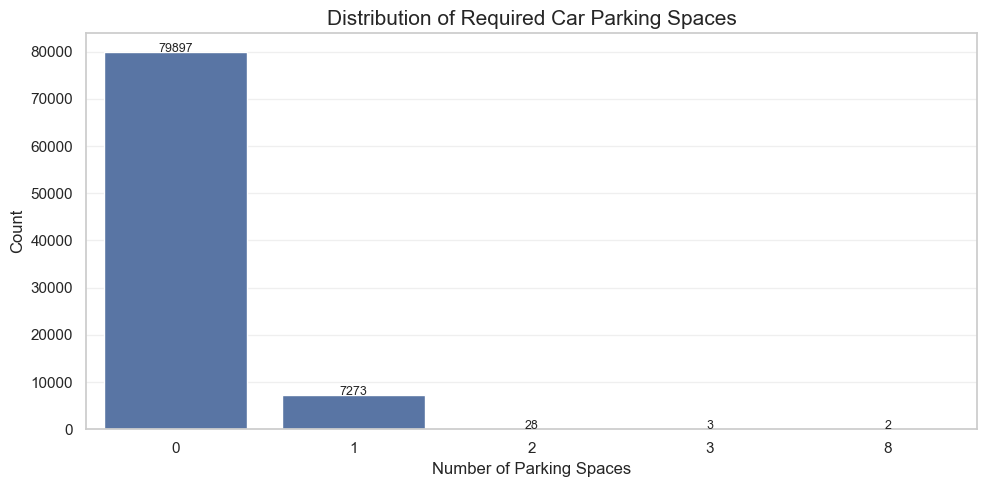

In [79]:
# Plot the distribution of Required Car Parking Spaces

plt.figure(figsize=(10,5))

counts = (
    df["required_car_parking_spaces"]
    .value_counts()
    .sort_index()
)

sns.barplot(
    x=counts.index,
    y=counts.values,
    color=PRIMARY_COLOR
)

for i, value in enumerate(counts.values):
    plt.text(
        i,
        value + 50,
        f"{value}",
        ha="center",
        fontsize=9
    )

plt.title("Distribution of Required Car Parking Spaces")
plt.xlabel("Number of Parking Spaces")
plt.ylabel("Count")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [80]:
# Identify outliers using the IQR method

print("🔽 Lowest 5 Values")
display(df["required_car_parking_spaces"].sort_values().head())

print("🔼 Highest 5 Values")
display(df["required_car_parking_spaces"].sort_values(ascending=False).head())

Q1 = df["required_car_parking_spaces"].quantile(0.25)
Q3 = df["required_car_parking_spaces"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = df[
    (df["required_car_parking_spaces"] < lower_bound) |
    (df["required_car_parking_spaces"] > upper_bound)
]

print(f"🚨 Number of Outliers: {len(outliers)}")

🔽 Lowest 5 Values


0        0
57210    0
57209    0
57208    0
57207    0
Name: required_car_parking_spaces, dtype: int64

🔼 Highest 5 Values


24049    8
24048    8
80052    3
32051    3
73304    3
Name: required_car_parking_spaces, dtype: int64

🚨 Number of Outliers: 7306


📝 Observation

The distribution of Required Car Parking Spaces is highly right-skewed, as most bookings (79,897) require no parking space, while 7,273 bookings request one parking space. Requests for two or more spaces are extremely rare, with a maximum of 8 spaces. The average is 0.08, and both the median and 75th percentile are 0, indicating that parking is not required for most bookings. Using the IQR method, 7,306 potential outliers were identified.

💼 Business Insight

Most guests do not require parking spaces, while only a small group arrives with private vehicles. Although this feature is highly imbalanced, it may still help distinguish different customer behaviors and improve booking cancellation prediction.

#### Total Special Requests

Objective : analyze the distribution of the total number of special requests made by guests for each booking.

Business Value : special requests reflect guests' preferences and engagement with the hotel. This feature may indicate customer commitment and could be associated with booking cancellation behavior.

In [81]:
# Display basic statistics for Total Special Requests

print("📌 Basic Statistics for Total Special Requests")

display(df["total_of_special_requests"].describe().to_frame().T)

📌 Basic Statistics for Total Special Requests


,count,mean,std,min,25%,50%,75%,max
total_of_special_requests,87203.0,0.699013,0.832053,0.0,0.0,0.0,1.0,5.0


In [82]:
# Display the frequency of each Total Special Requests value

print("📌 Value Counts for Total Special Requests")

display(df["total_of_special_requests"].value_counts().sort_index())

📌 Value Counts for Total Special Requests


total_of_special_requests
0    43770
1    28971
2    11793
3     2313
4      320
5       36
Name: count, dtype: int64

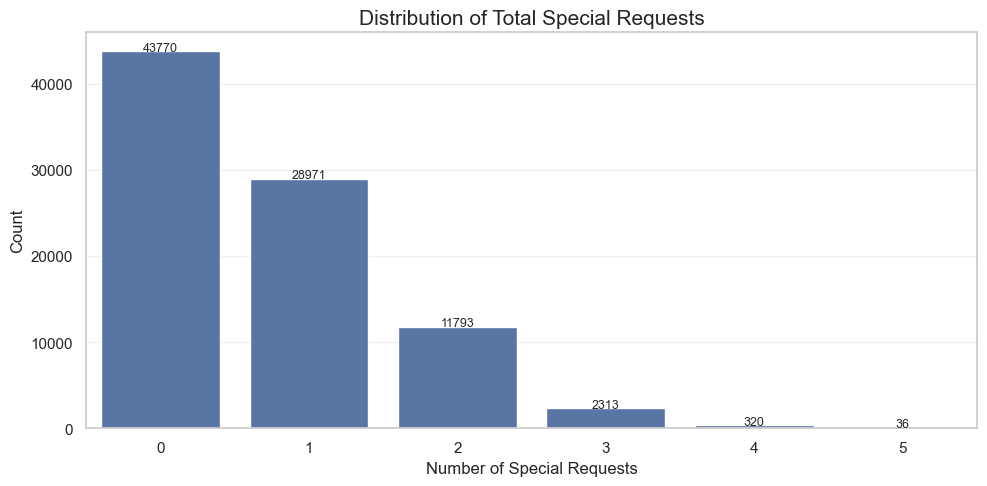

In [83]:
# Plot the distribution of Total Special Requests

plt.figure(figsize=(10,5))

counts = (
    df["total_of_special_requests"]
    .value_counts()
    .sort_index()
)

sns.barplot(
    x=counts.index,
    y=counts.values,
    color=PRIMARY_COLOR
)

for i, value in enumerate(counts.values):
    plt.text(
        i,
        value + 50,
        f"{value}",
        ha="center",
        fontsize=9
    )

plt.title("Distribution of Total Special Requests")
plt.xlabel("Number of Special Requests")
plt.ylabel("Count")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [84]:
# Identify outliers using the IQR method

print("🔽 Lowest 5 Values")
display(df["total_of_special_requests"].sort_values().head())

print("🔼 Highest 5 Values")
display(df["total_of_special_requests"].sort_values(ascending=False).head())

Q1 = df["total_of_special_requests"].quantile(0.25)
Q3 = df["total_of_special_requests"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = df[
    (df["total_of_special_requests"] < lower_bound) |
    (df["total_of_special_requests"] > upper_bound)
]

print(f"🚨 Number of Outliers: {len(outliers)}")

🔽 Lowest 5 Values


0        0
45445    0
45447    0
45448    0
45450    0
Name: total_of_special_requests, dtype: int64

🔼 Highest 5 Values


72714    5
22645    5
79468    5
83431    5
26860    5
Name: total_of_special_requests, dtype: int64

🚨 Number of Outliers: 2669


📝 Observation

The distribution of Total Special Requests is right-skewed, with most bookings having 0 or 1 special request. Specifically, 43,770 bookings have no special requests, while 28,971 have one request. The average is approximately 0.70 requests per booking, with a median of 0. Bookings with 3 or more requests are uncommon, and the maximum observed value is 5 requests. Using the IQR method, 2,669 potential outliers were identified.

💼 Business Insight

Most guests make few or no special requests, while only a small group requests multiple services. Since special requests may indicate stronger customer engagement and booking commitment, this feature could be valuable for predicting hotel booking cancellations.

###  5.2.4 Categorical Features

#### Hotel

Objective : analyze the distribution of hotel types to understand how bookings are divided between Resort Hotels and City Hotels.

Business Value : the hotel type may influence customer behavior, booking patterns, and cancellation rates. Understanding its distribution provides useful context before exploring its relationship with cancellations.

In [85]:
# Display the frequency of each Hotel type

print("📌 Value Counts for Hotel")

display(df["hotel"].value_counts())

📌 Value Counts for Hotel


hotel
City Hotel      53272
Resort Hotel    33931
Name: count, dtype: int64

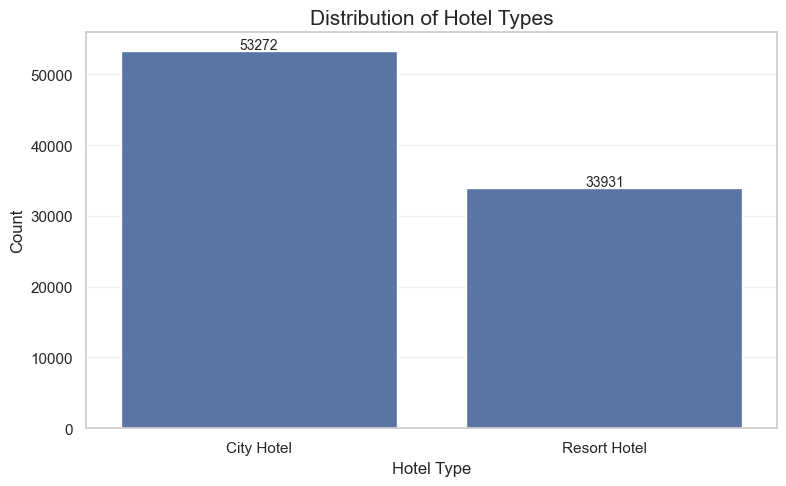

In [86]:
# Plot the distribution of Hotel types

plt.figure(figsize=(8,5))

counts = df["hotel"].value_counts()

sns.barplot(
    x=counts.index,
    y=counts.values,
    color=PRIMARY_COLOR
)

for i, value in enumerate(counts.values):
    plt.text(
        i,
        value + 300,
        f"{value}",
        ha="center",
        fontsize=10
    )

plt.title("Distribution of Hotel Types")
plt.xlabel("Hotel Type")
plt.ylabel("Count")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

📝 Observation

The dataset contains 53,272 City Hotel bookings and 33,931 Resort Hotel bookings. This indicates that City Hotels account for the majority of bookings, representing approximately 61% of the dataset, while Resort Hotels account for about 39%. The distribution is moderately imbalanced but still includes a substantial number of bookings from both hotel types.

💼 Business Insight

The higher number of City Hotel bookings suggests greater demand for urban accommodations. Since customer behavior may differ between City Hotels and Resort Hotels, the hotel type is expected to be an important feature for understanding booking patterns and predicting cancellations.

#### Meal

Objective : analyze the distribution of meal plans selected by guests across all hotel bookings.

Business Value : the selected meal plan reflects guests' preferences and booking choices. It may also be associated with customer type, travel purpose, and booking cancellation behavior.

In [87]:
# Display the frequency of each Meal type

print("📌 Value Counts for Meal")

display(df["meal"].value_counts())

📌 Value Counts for Meal


meal
BB           67883
SC            9391
HB            9079
Undefined      490
FB             360
Name: count, dtype: int64

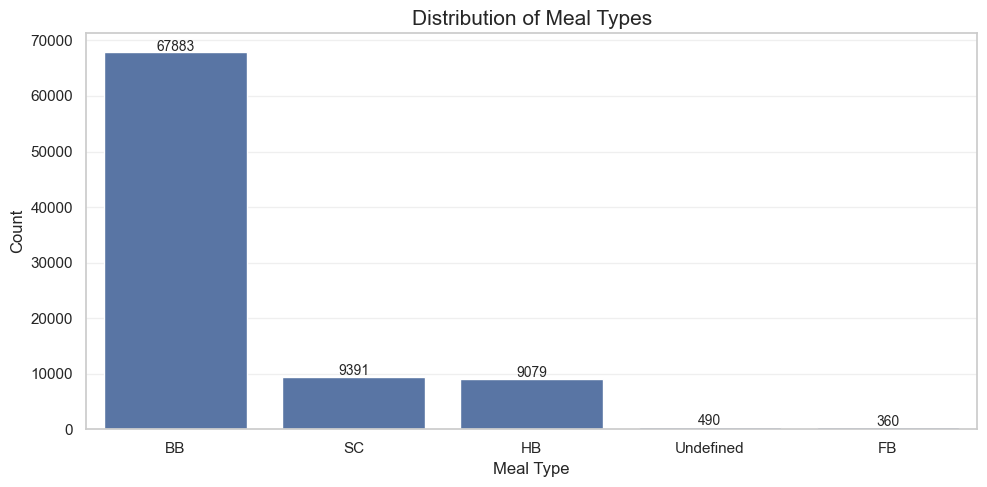

In [88]:
# Plot the distribution of Meal types

plt.figure(figsize=(10,5))

counts = df["meal"].value_counts()

sns.barplot(
    x=counts.index,
    y=counts.values,
    color=PRIMARY_COLOR
)

for i, value in enumerate(counts.values):
    plt.text(
        i,
        value + 300,
        f"{value}",
        ha="center",
        fontsize=10
    )

plt.title("Distribution of Meal Types")
plt.xlabel("Meal Type")
plt.ylabel("Count")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

📝 Observation

The BB (Bed & Breakfast) meal plan is the most common choice, with 67,883 bookings, accounting for the majority of reservations. The SC (Self Catering) and HB (Half Board) meal plans are selected at similar frequencies, with 9,391 and 9,079 bookings, respectively. Meanwhile, Undefined and FB (Full Board) meal plans are rarely selected, with fewer than 500 bookings each. Overall, the distribution is highly imbalanced, with BB dominating the dataset.

💼 Business Insight

The strong preference for the BB meal plan suggests that most guests choose a basic breakfast option, while more comprehensive meal packages are less common. Since meal selection may reflect different customer preferences and travel purposes, this feature could provide useful information for understanding booking behavior and predicting cancellations.

#### Country

Objective : analyze the distribution of guest countries to identify the main markets contributing to hotel bookings.

Business Value : understanding where guests come from helps identify key customer markets and supports marketing, pricing, and demand forecasting strategies.

In [89]:
# Display the top 10 countries by number of bookings

print("📌 Top 10 Countries")

display(df["country"].value_counts().head(10))

📌 Top 10 Countries


country
PRT    27779
GBR    10422
FRA     8823
ESP     7244
DEU     5385
ITA     3061
IRL     3015
BEL     2081
BRA     1993
NLD     1910
Name: count, dtype: int64

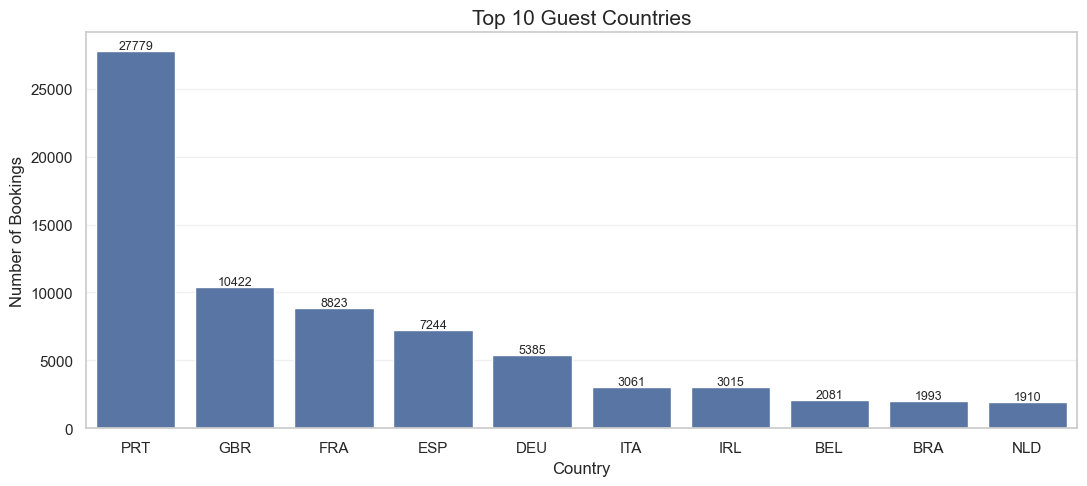

In [90]:
# Plot the distribution of the top 10 countries

plt.figure(figsize=(11,5))

counts = df["country"].value_counts().head(10)

sns.barplot(
    x=counts.index,
    y=counts.values,
    color=PRIMARY_COLOR
)

for i, value in enumerate(counts.values):
    plt.text(
        i,
        value + 150,
        f"{value}",
        ha="center",
        fontsize=9
    )

plt.title("Top 10 Guest Countries")
plt.xlabel("Country")
plt.ylabel("Number of Bookings")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

📝 Observation

The majority of hotel bookings come from Portugal (PRT), with 27,779 bookings, making it the largest customer market by a wide margin. The United Kingdom (GBR) and France (FRA) follow with 10,422 and 8,823 bookings, respectively. Other major markets include Spain (ESP), Germany (DEU), Italy (ITA), Ireland (IRL), Belgium (BEL), Brazil (BRA), and Netherlands (NLD). The distribution shows that bookings are concentrated in a few countries, particularly Portugal.

💼 Business Insight

The hotel primarily serves guests from Portugal and several European countries, indicating that its customer base is largely regional. Understanding these key markets can help the hotel optimize marketing campaigns, pricing strategies, and customer services, while the country feature may also contribute to predicting booking cancellations.

#### Market Segment

Objective : analyze the distribution of booking market segments to identify the primary sources through which guests make hotel reservations.

Business Value : different market segments represent different customer acquisition channels and booking behaviors. Understanding their distribution helps identify the hotel's main customer sources and can improve marketing and revenue management strategies.

In [91]:
# Display the frequency of each Market Segment

print("📌 Value Counts for Market Segment")

display(df["market_segment"].value_counts())

📌 Value Counts for Market Segment


market_segment
Online TA        51548
Offline TA/TO    13852
Direct           11774
Groups            4919
Corporate         4190
Complementary      692
Aviation           226
Undefined            2
Name: count, dtype: int64

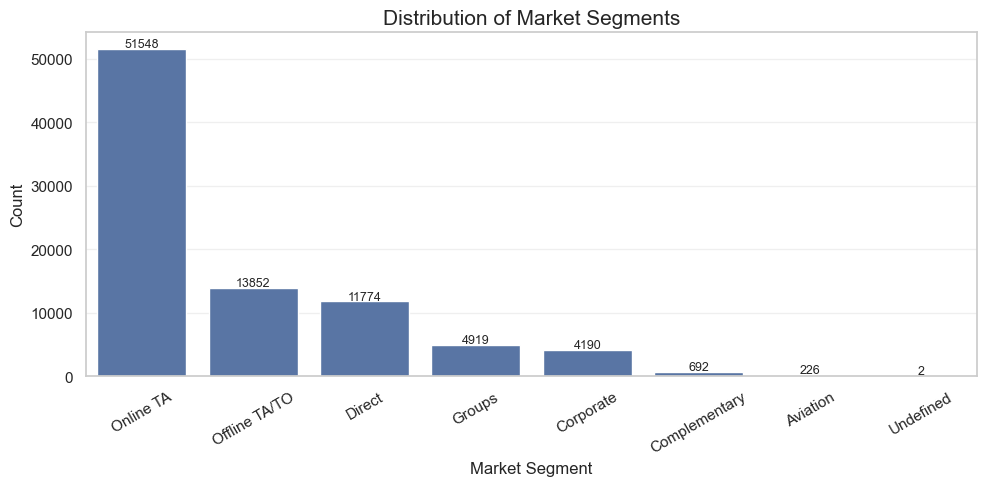

In [92]:
# Plot the distribution of Market Segments

plt.figure(figsize=(10,5))

counts = df["market_segment"].value_counts()

sns.barplot(
    x=counts.index,
    y=counts.values,
    color=PRIMARY_COLOR
)

for i, value in enumerate(counts.values):
    plt.text(
        i,
        value + 300,
        f"{value}",
        ha="center",
        fontsize=9
    )

plt.title("Distribution of Market Segments")
plt.xlabel("Market Segment")
plt.ylabel("Count")

plt.xticks(rotation=30)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

📝 Observation

The Online TA segment is the dominant booking channel, with 51,548 bookings, accounting for the majority of reservations. It is followed by Offline TA/TO (13,852 bookings) and Direct bookings (11,774 bookings). The Groups and Corporate segments contribute a moderate number of bookings, while Complementary, Aviation, and Undefined bookings are relatively rare. Overall, the distribution is highly concentrated in the Online TA segment.

💼 Business Insight

The hotel's bookings rely heavily on Online Travel Agencies (OTAs), indicating that third-party booking platforms are the primary source of customers. Since booking behavior and cancellation rates often differ across market segments, market_segment is expected to be an important feature for predicting booking cancellations.

#### Distribution Channel

Objective : analyze the distribution of booking distribution channels to identify how reservations are delivered to the hotel.

Business Value : distribution channels represent the pathways through which bookings reach the hotel. Understanding their distribution helps evaluate the effectiveness of sales channels and supports revenue management decisions.

In [93]:
# Display the frequency of each Distribution Channel

print("📌 Value Counts for Distribution Channel")

display(df["distribution_channel"].value_counts())

📌 Value Counts for Distribution Channel


distribution_channel
TA/TO        69020
Direct       12945
Corporate     5052
GDS            181
Undefined        5
Name: count, dtype: int64

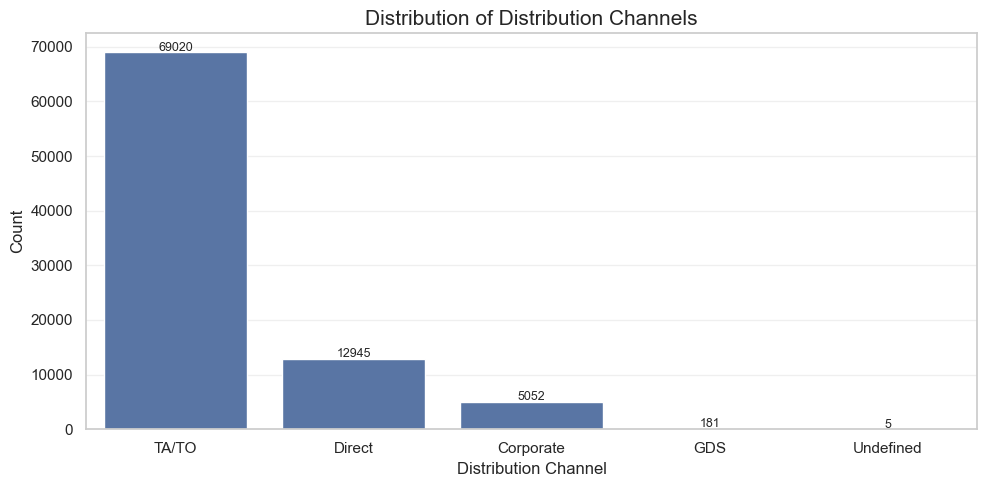

In [94]:
# Plot the distribution of Distribution Channels

plt.figure(figsize=(10,5))

counts = df["distribution_channel"].value_counts()

sns.barplot(
    x=counts.index,
    y=counts.values,
    color=PRIMARY_COLOR
)

for i, value in enumerate(counts.values):
    plt.text(
        i,
        value + 300,
        f"{value}",
        ha="center",
        fontsize=9
    )

plt.title("Distribution of Distribution Channels")
plt.xlabel("Distribution Channel")
plt.ylabel("Count")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

📝 Observation

The TA/TO (Travel Agents/Tour Operators) channel dominates the booking distribution, with 69,020 bookings, representing the vast majority of reservations. The Direct channel ranks second with 12,945 bookings, followed by the Corporate channel with 5,052 bookings. Meanwhile, GDS (Global Distribution System) and Undefined channels contribute only a very small number of bookings. Overall, the distribution is highly concentrated in the TA/TO channel.

💼 Business Insight

The results indicate that the hotel relies heavily on travel agents and tour operators to receive bookings, while direct reservations account for a much smaller share. Since customer behavior may vary across distribution channels, distribution_channel is likely to be an important feature for predicting booking cancellations.

#### Reserved Room Type

Objective : analyze the distribution of reserved room types to understand which room categories are most frequently booked.

Business Value : the reserved room type reflects customer preferences and booking patterns. Identifying the most requested room categories helps optimize room allocation, pricing strategies, and demand forecasting.

In [95]:
# Display the frequency of each Reserved Room Type

print("📌 Value Counts for Reserved Room Type")

display(df["reserved_room_type"].value_counts())

📌 Value Counts for Reserved Room Type


reserved_room_type
A    56413
D    17375
E     6034
F     2819
G     2050
B      996
C      914
H      596
L        6
Name: count, dtype: int64

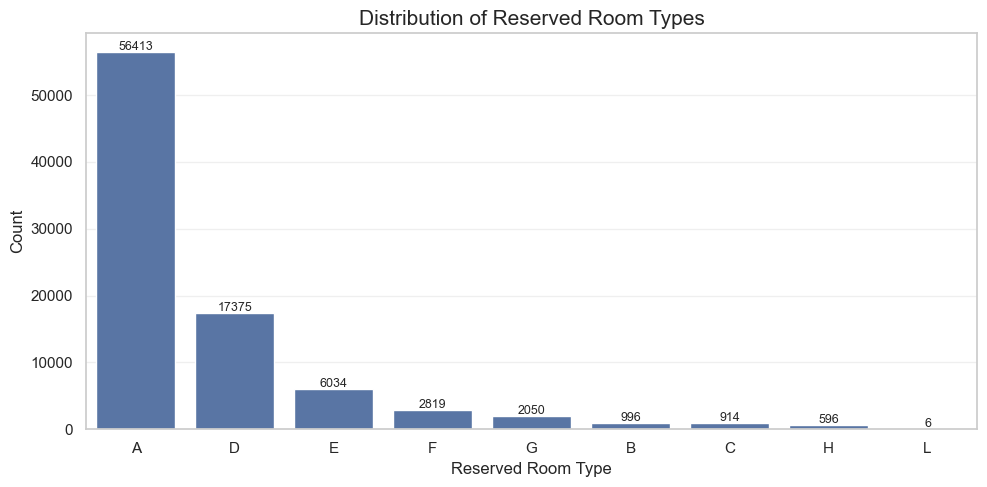

In [96]:
# Plot the distribution of Reserved Room Types

plt.figure(figsize=(10,5))

counts = df["reserved_room_type"].value_counts()

sns.barplot(
    x=counts.index,
    y=counts.values,
    color=PRIMARY_COLOR
)

for i, value in enumerate(counts.values):
    plt.text(
        i,
        value + 300,
        f"{value}",
        ha="center",
        fontsize=9
    )

plt.title("Distribution of Reserved Room Types")
plt.xlabel("Reserved Room Type")
plt.ylabel("Count")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

📝 Observation

The distribution of Reserved Room Type is highly imbalanced. Room Type A is the most frequently reserved, with 56,413 bookings, accounting for the majority of reservations. It is followed by Room Type D (17,375) and Room Type E (6,034), while the remaining room types are booked much less frequently. The least reserved room type is L, with only 6 bookings, indicating that some room categories are rarely requested.

💼 Business Insight

The results suggest that customer demand is concentrated in a small number of room categories, particularly Room Type A. This information can help hotel management optimize room inventory and pricing strategies. Additionally, the reserved_room_type feature may contribute to predicting booking cancellations, as cancellation behavior could differ across room categories.

#### Assigned Room Type

Objective : analyze the distribution of assigned room types to understand which room categories guests actually received.

Business Value : comparing assigned room types helps evaluate room allocation efficiency and identify whether guests are frequently assigned different room categories than originally reserved.

In [97]:
# Display the frequency of each Assigned Room Type

print("📌 Value Counts for Assigned Room Type")

display(df["assigned_room_type"].value_counts())

📌 Value Counts for Assigned Room Type


assigned_room_type
A    46271
D    22409
E     7188
F     3625
G     2495
C     2160
B     1811
H      705
I      353
K      185
L        1
Name: count, dtype: int64

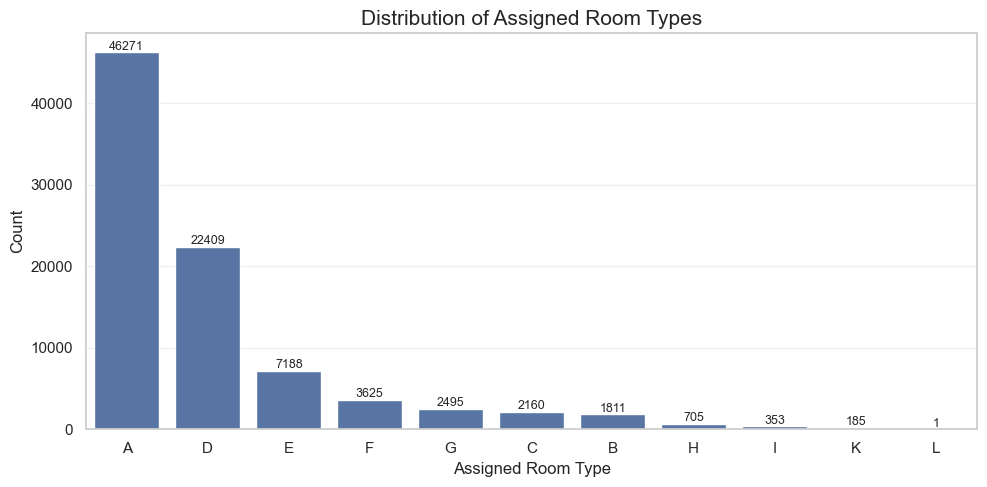

In [98]:
# Plot the distribution of Assigned Room Types

plt.figure(figsize=(10,5))

counts = df["assigned_room_type"].value_counts()

sns.barplot(
    x=counts.index,
    y=counts.values,
    color=PRIMARY_COLOR
)

for i, value in enumerate(counts.values):
    plt.text(
        i,
        value + 300,
        f"{value}",
        ha="center",
        fontsize=9
    )

plt.title("Distribution of Assigned Room Types")
plt.xlabel("Assigned Room Type")
plt.ylabel("Count")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

📝 Observation

The distribution of Assigned Room Type is highly concentrated in a few categories. Room Type A is the most frequently assigned, with 46,271 bookings, followed by Room Type D (22,409) and Room Type E (7,188). The remaining room types account for a relatively small proportion of bookings, while Room Type L appears only once. Compared with the reserved room types, the assigned room types show a slightly different distribution, suggesting that some guests were assigned a different room category than originally booked.

💼 Business Insight

The hotel primarily assigns guests to a limited number of room categories, with Room Types A and D serving most bookings. The differences between reserved and assigned room types may reflect room upgrades, operational adjustments, or availability constraints. Therefore, assigned_room_type could be a useful feature for understanding hotel operations and predicting booking cancellations.

#### Deposit Type

Objective : analyze the distribution of deposit types to understand the payment policies applied to hotel bookings.

Business Value : deposit type reflects the booking payment policy and may influence customer commitment and cancellation behavior, making it an important feature for predictive analysis.

In [99]:
# Display the frequency of each Deposit Type

print("📌 Value Counts for Deposit Type")

display(df["deposit_type"].value_counts())

📌 Value Counts for Deposit Type


deposit_type
No Deposit    86058
Non Refund     1038
Refundable      107
Name: count, dtype: int64

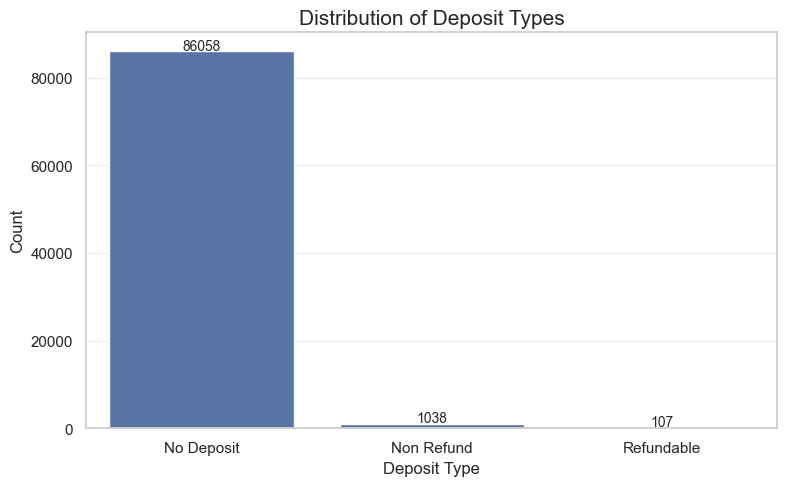

In [100]:
# Plot the distribution of Deposit Types

plt.figure(figsize=(8,5))

counts = df["deposit_type"].value_counts()

sns.barplot(
    x=counts.index,
    y=counts.values,
    color=PRIMARY_COLOR
)

for i, value in enumerate(counts.values):
    plt.text(
        i,
        value + 300,
        f"{value}",
        ha="center",
        fontsize=10
    )

plt.title("Distribution of Deposit Types")
plt.xlabel("Deposit Type")
plt.ylabel("Count")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

📝 Observation

The No Deposit policy is overwhelmingly dominant, with 86,058 bookings, representing almost all reservations. In contrast, Non Refund accounts for only 1,038 bookings, while Refundable deposits are extremely rare, with just 107 bookings. This indicates that the hotel primarily accepts bookings without requiring an upfront deposit.

💼 Business Insight

The hotel follows a flexible booking policy, as the vast majority of guests are not required to pay a deposit before arrival. Since the deposit policy may affect customer commitment and cancellation behavior, deposit_type is expected to be an important feature for predicting booking cancellations.

#### Customer Type

Objective : analyze the distribution of customer types to understand the different categories of hotel guests.

Business Value : customer type reflects guest behavior and booking characteristics. Different customer categories may have different cancellation patterns, making this feature valuable for predictive modeling.

In [101]:
# Display the frequency of each Customer Type

print("📌 Value Counts for Customer Type")

display(df["customer_type"].value_counts())

📌 Value Counts for Customer Type


customer_type
Transient          71844
Transient-Party    11683
Contract            3135
Group                541
Name: count, dtype: int64

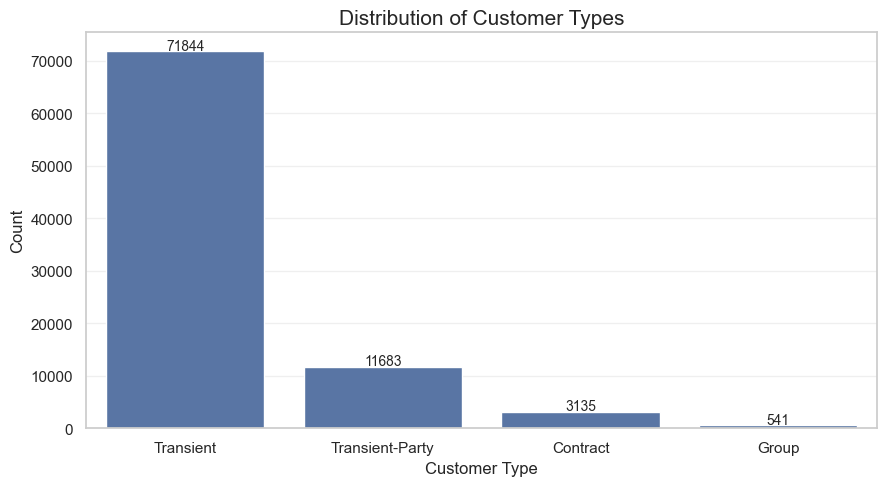

In [102]:
# Plot the distribution of Customer Types

plt.figure(figsize=(9,5))

counts = df["customer_type"].value_counts()

sns.barplot(
    x=counts.index,
    y=counts.values,
    color=PRIMARY_COLOR
)

for i, value in enumerate(counts.values):
    plt.text(
        i,
        value + 300,
        f"{value}",
        ha="center",
        fontsize=10
    )

plt.title("Distribution of Customer Types")
plt.xlabel("Customer Type")
plt.ylabel("Count")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

📝 Observation

The Transient customer type dominates the dataset, with 71,844 bookings, accounting for the vast majority of reservations. It is followed by Transient-Party (11,683), while Contract (3,135) and Group (541) customers represent only a small share of total bookings. This indicates that most hotel reservations come from individual travelers rather than organized groups or contracted clients.

💼 Business Insight

The hotel mainly serves Transient guests, making this segment the most influential in booking trends and operational planning. Since different customer types are likely to exhibit different booking and cancellation behaviors, customer_type is expected to be an important predictor in the cancellation model.

#### Reservation Status

Objective : analyze the distribution of reservation outcomes to understand the final status of hotel bookings.

Business Value : reservation status summarizes the final outcome of each booking. Although it provides useful business insights, it should not be used as a predictive feature because it is determined after the booking process is completed.

In [103]:
# Display the frequency of each Reservation Status

print("📌 Value Counts for Reservation Status")

display(df["reservation_status"].value_counts())

📌 Value Counts for Reservation Status


reservation_status
Check-Out    63195
Canceled     22995
No-Show       1013
Name: count, dtype: int64

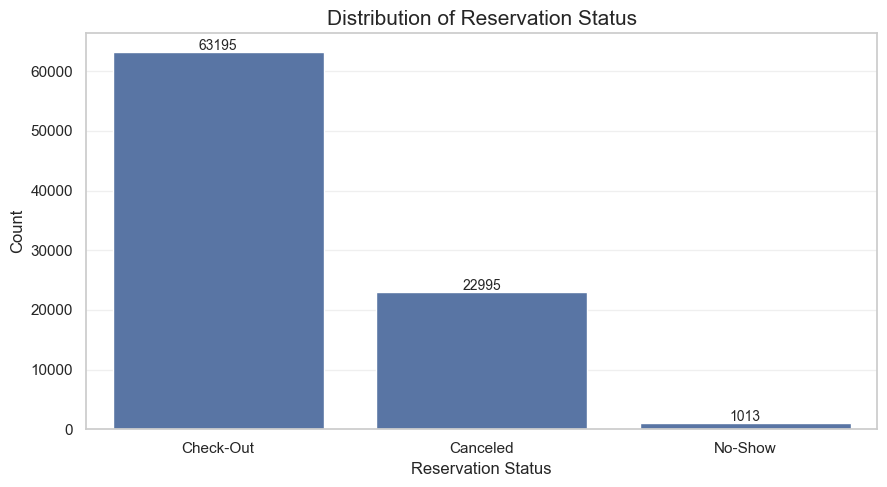

In [104]:
# Plot the distribution of Reservation Status

plt.figure(figsize=(9,5))

counts = df["reservation_status"].value_counts()

sns.barplot(
    x=counts.index,
    y=counts.values,
    color=PRIMARY_COLOR
)

for i, value in enumerate(counts.values):
    plt.text(
        i,
        value + 300,
        f"{value}",
        ha="center",
        fontsize=10
    )

plt.title("Distribution of Reservation Status")
plt.xlabel("Reservation Status")
plt.ylabel("Count")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

📝 Observation

The Check-Out status is the most common outcome, with 63,195 bookings, followed by Canceled (22,995). No-Show bookings are relatively rare, with only 1,013 cases. This indicates that most reservations are completed successfully, while cancellations represent a significant portion of bookings.

💼 Business Insight

Although reservation_status provides valuable information about booking outcomes, it must not be used as a predictive feature because it is determined after the booking process is completed. Using it would introduce data leakage and lead to unrealistically high model performance.

## 5.3 Bivariate Analysis

### Hotel vs Cancellation

In [105]:
# Calculate the cancellation rate by hotel type

hotel_cancel = (
    df.groupby("hotel")["is_canceled"]
    .mean()
    .mul(100)
    .reset_index(name="Cancellation Rate")
)

display(hotel_cancel)

,hotel,Cancellation Rate
0,City Hotel,30.100240
1,Resort Hotel,23.497686


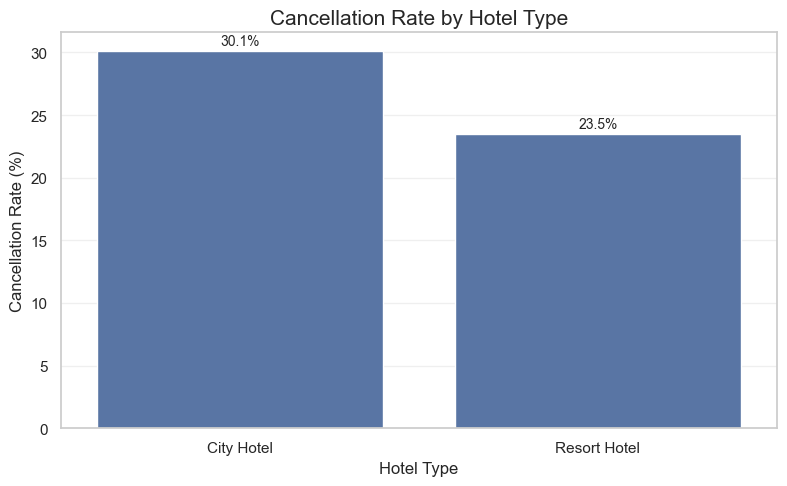

In [106]:
# Plot the cancellation rate by hotel type

plt.figure(figsize=(8,5))

sns.barplot(
    data=hotel_cancel,
    x="hotel",
    y="Cancellation Rate",
    color=PRIMARY_COLOR
)

for i, value in enumerate(hotel_cancel["Cancellation Rate"]):
    plt.text(
        i,
        value + 0.5,
        f"{value:.1f}%",
        ha="center",
        fontsize=10
    )

plt.title("Cancellation Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate (%)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [107]:
# Display booking counts by hotel type and cancellation status

pd.crosstab(
    df["hotel"],
    df["is_canceled"],
    margins=True
)

is_canceled,0,1,All
hotel,,,
City Hotel,37237,16035,53272
Resort Hotel,25958,7973,33931
All,63195,24008,87203


📝 Observation

City Hotels have a higher cancellation rate (30.1%) than Resort Hotels (23.5%).
Around 3 out of every 10 City Hotel bookings are canceled.

💼 Business Insight

City Hotels should focus more on cancellation reduction strategies such as flexible pricing, reminders, or partial prepayment.
Resort Hotels have more stable bookings and lower cancellation risk.

### Meal Type vs Cancellation

In [108]:
# Calculate the cancellation rate by meal type

meal_cancel = (
    df.groupby("meal")["is_canceled"]
    .mean()
    .mul(100)
    .reset_index(name="Cancellation Rate")
)

display(meal_cancel)

,meal,Cancellation Rate
0,BB,26.578083
1,FB,27.500000
2,HB,26.974336
3,SC,35.523373
4,Undefined,16.734694


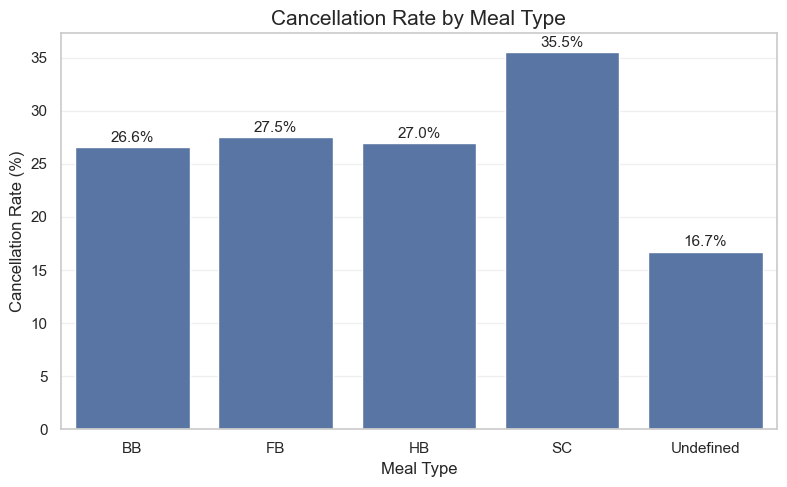

In [109]:
# Plot the cancellation rate by meal type

plt.figure(figsize=(8,5))

sns.barplot(
    data=meal_cancel,
    x="meal",
    y="Cancellation Rate",
    color=PRIMARY_COLOR
)

for i, value in enumerate(meal_cancel["Cancellation Rate"]):
    plt.text(i, value+0.5, f"{value:.1f}%", ha="center")

plt.title("Cancellation Rate by Meal Type")
plt.xlabel("Meal Type")
plt.ylabel("Cancellation Rate (%)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

📝 Observation

SC (Self Catering) has the highest cancellation rate (35.5%).
Undefined has the lowest rate but contains very few records.
BB, HB, and FB have similar cancellation rates.

💼 Business Insight

Guests selecting Self Catering are more likely to cancel.
Hotels could review pricing or booking policies for SC bookings.

### Market Segment vs Cancellation

In [110]:
# Calculate the cancellation rate by market segment

segment_cancel = (
    df.groupby("market_segment")["is_canceled"]
    .mean()
    .mul(100)
    .reset_index(name="Cancellation Rate")
)

display(segment_cancel)

,market_segment,Cancellation Rate
0,Aviation,19.911504
1,Complementary,12.283237
2,Corporate,12.147971
3,Direct,14.752845
4,Groups,27.078675
5,Offline TA/TO,14.842622
6,Online TA,35.388376
7,Undefined,100.000000


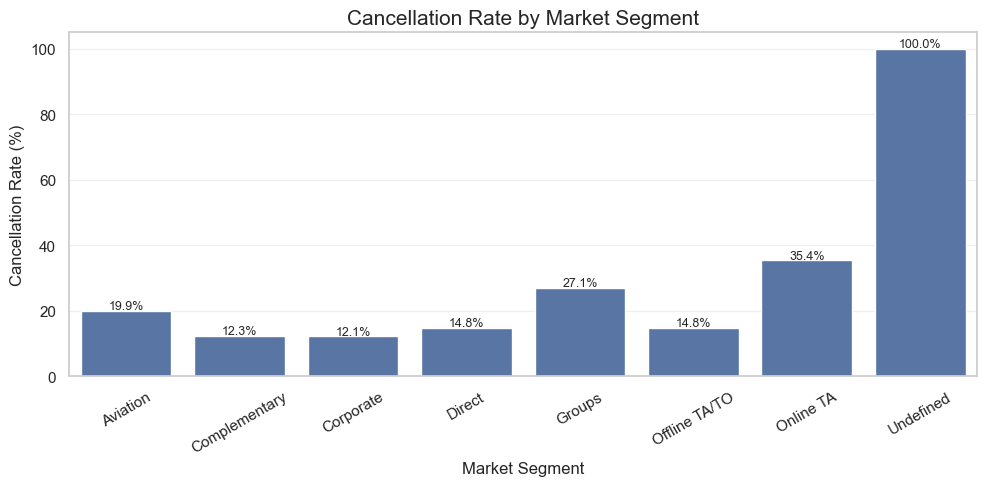

In [111]:
# Plot the cancellation rate by market segment

plt.figure(figsize=(10,5))

sns.barplot(
    data=segment_cancel,
    x="market_segment",
    y="Cancellation Rate",
    color=PRIMARY_COLOR
)

for i, value in enumerate(segment_cancel["Cancellation Rate"]):
    plt.text(i, value+0.5, f"{value:.1f}%", ha="center", fontsize=9)

plt.xticks(rotation=30)

plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Cancellation Rate (%)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

📝 Observation

Online TA has the highest meaningful cancellation rate (35.4%).
Corporate and Direct bookings have much lower cancellation rates.

💼 Business Insight

Online Travel Agencies generate many bookings but also many cancellations.
Encouraging direct bookings could reduce cancellation rates.

### Distribution Channel vs Cancellation

In [112]:
# Calculate the cancellation rate by distribution channel

channel_cancel = (
    df.groupby("distribution_channel")["is_canceled"]
    .mean()
    .mul(100)
    .reset_index(name="Cancellation Rate")
)

display(channel_cancel)

,distribution_channel,Cancellation Rate
0,Corporate,12.787015
1,Direct,14.855156
2,GDS,19.889503
3,TA/TO,31.004057
4,Undefined,80.000000


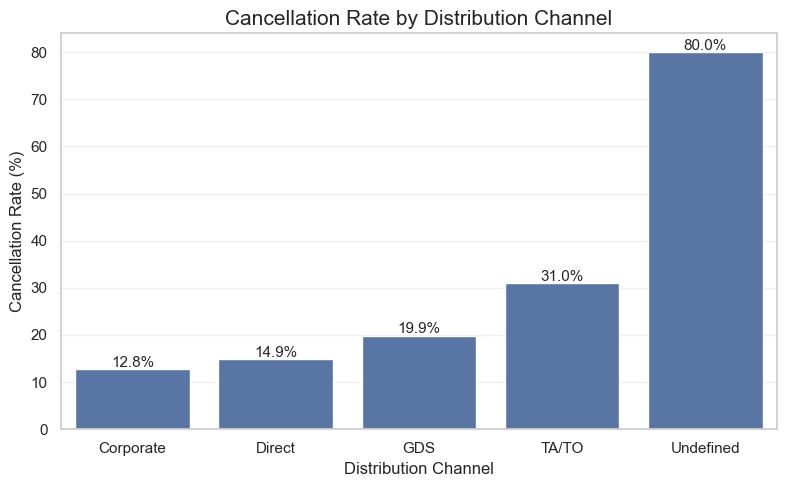

In [113]:
# Plot the cancellation rate by distribution channel

plt.figure(figsize=(8,5))

sns.barplot(
    data=channel_cancel,
    x="distribution_channel",
    y="Cancellation Rate",
    color=PRIMARY_COLOR
)

for i, value in enumerate(channel_cancel["Cancellation Rate"]):
    plt.text(i, value+0.5, f"{value:.1f}%", ha="center")

plt.title("Cancellation Rate by Distribution Channel")
plt.xlabel("Distribution Channel")
plt.ylabel("Cancellation Rate (%)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

📝 Observation

TA/TO has the highest cancellation rate among the major channels.
Direct and Corporate channels are considerably more stable.

💼 Business Insight

Increasing direct bookings can improve booking stability and reduce cancellation risk.

### Deposit Type vs Cancellation

In [114]:
# Calculate the cancellation rate by deposit type

deposit_cancel = (
    df.groupby("deposit_type")["is_canceled"]
    .mean()
    .mul(100)
    .reset_index(name="Cancellation Rate")
)

display(deposit_cancel)

,deposit_type,Cancellation Rate
0,No Deposit,26.724999
1,Non Refund,94.701349
2,Refundable,24.299065


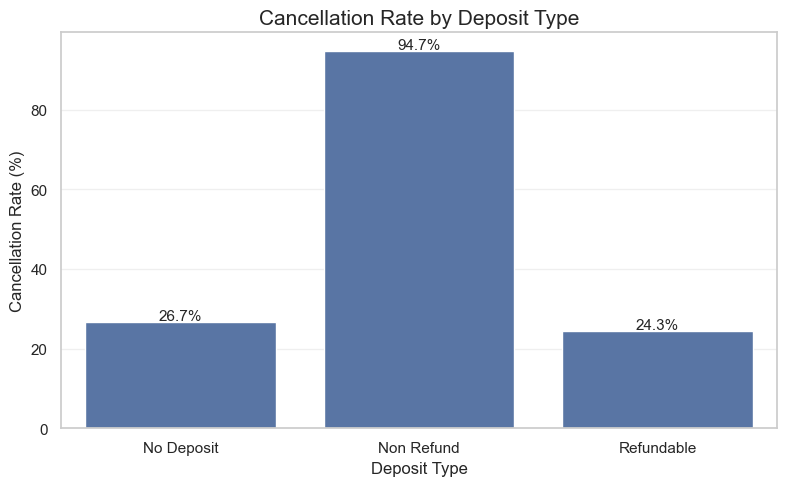

In [115]:
# Plot the cancellation rate by deposit type

plt.figure(figsize=(8,5))

sns.barplot(
    data=deposit_cancel,
    x="deposit_type",
    y="Cancellation Rate",
    color=PRIMARY_COLOR
)

for i, value in enumerate(deposit_cancel["Cancellation Rate"]):
    plt.text(i, value+0.5, f"{value:.1f}%", ha="center")

plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Cancellation Rate (%)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

📝 Observation

Non Refund bookings show an extremely high cancellation rate (94.7%).
No Deposit and Refundable bookings have much lower cancellation rates.

💼 Business Insight

Deposit policy is a strong indicator of booking behavior and should be considered in cancellation prediction.

### Customer Type vs Cancellation

In [116]:
# Calculate the cancellation rate by customer type

customer_cancel = (
    df.groupby("customer_type")["is_canceled"]
    .mean()
    .mul(100)
    .reset_index(name="Cancellation Rate")
)

display(customer_cancel)

,customer_type,Cancellation Rate
0,Contract,16.331738
1,Group,9.796673
2,Transient,30.148655
3,Transient-Party,15.261491


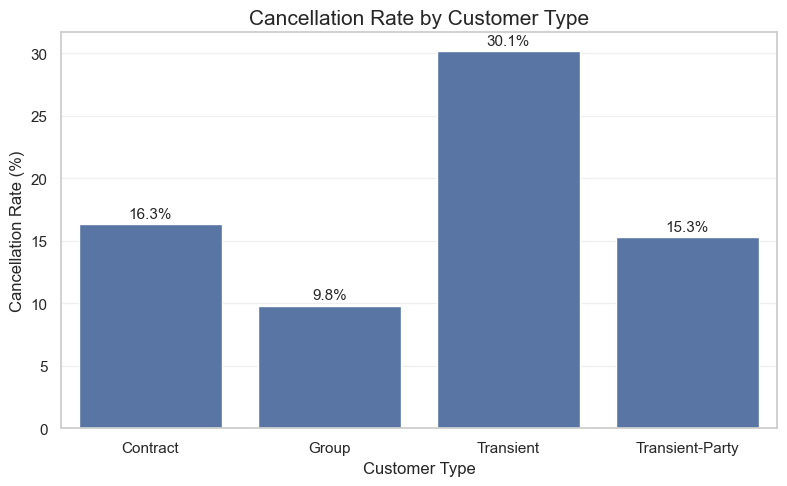

In [117]:
# Plot the cancellation rate by customer type

plt.figure(figsize=(8,5))

sns.barplot(
    data=customer_cancel,
    x="customer_type",
    y="Cancellation Rate",
    color=PRIMARY_COLOR
)

for i, value in enumerate(customer_cancel["Cancellation Rate"]):
    plt.text(i, value+0.5, f"{value:.1f}%", ha="center")

plt.title("Cancellation Rate by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Cancellation Rate (%)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

📝 Observation

Transient customers have the highest cancellation rate.
Group customers have the lowest cancellation rate.

💼 Business Insight

Individual travelers are more likely to cancel than groups or contract customers.

### Repeated Guest vs Cancellation

In [118]:
# Calculate the cancellation rate by repeated guest status

repeat_cancel = (
    df.groupby("is_repeated_guest")["is_canceled"]
    .mean()
    .mul(100)
    .reset_index(name="Cancellation Rate")
)

display(repeat_cancel)

,is_repeated_guest,Cancellation Rate
0,0,28.325382
1,1,7.731192


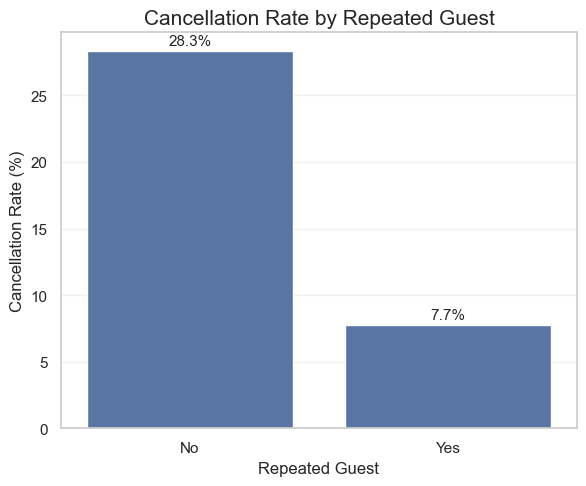

In [119]:
# Plot the cancellation rate by repeated guest status

plt.figure(figsize=(6,5))

sns.barplot(
    data=repeat_cancel,
    x="is_repeated_guest",
    y="Cancellation Rate",
    color=PRIMARY_COLOR
)

for i, value in enumerate(repeat_cancel["Cancellation Rate"]):
    plt.text(i, value+0.5, f"{value:.1f}%", ha="center")

plt.xticks([0,1],["No","Yes"])

plt.title("Cancellation Rate by Repeated Guest")
plt.xlabel("Repeated Guest")
plt.ylabel("Cancellation Rate (%)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

📝 Observation

Repeated guests cancel far less frequently than first-time guests.

💼 Business Insight

Loyalty programs can help reduce future cancellations.

### Lead Time vs Cancellation

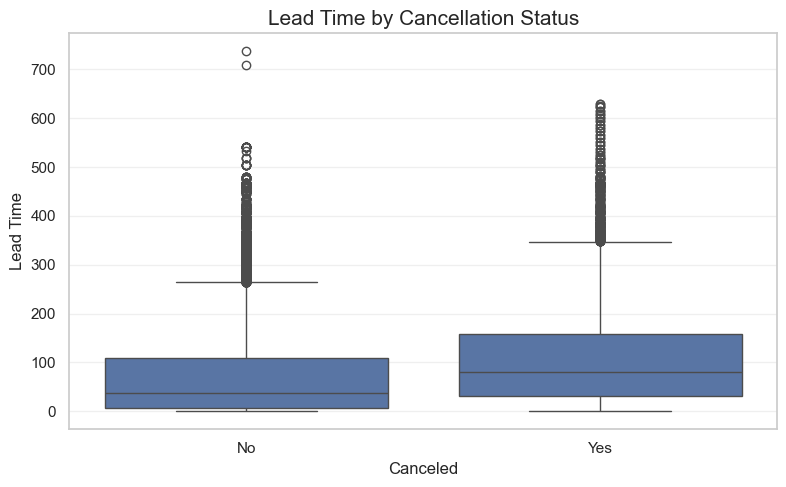

In [120]:
# Compare lead time by cancellation status

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="is_canceled",
    y="lead_time",
    color=PRIMARY_COLOR
)

plt.xticks([0,1],["No","Yes"])

plt.title("Lead Time by Cancellation Status")
plt.xlabel("Canceled")
plt.ylabel("Lead Time")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

📝 Observation

Canceled bookings generally have much longer lead times.

💼 Business Insight

Long lead times increase booking uncertainty and cancellation risk.

### ADR vs Cancellation

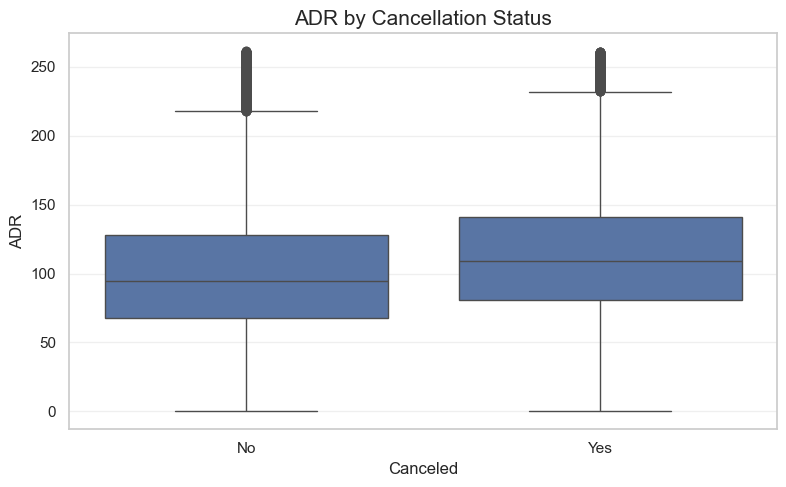

In [121]:
# Compare ADR by cancellation status

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df[df["adr"]<=df["adr"].quantile(0.99)],
    x="is_canceled",
    y="adr",
    color=PRIMARY_COLOR
)

plt.xticks([0,1],["No","Yes"])

plt.title("ADR by Cancellation Status")
plt.xlabel("Canceled")
plt.ylabel("ADR")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

📝 Observation

Canceled bookings tend to have slightly higher ADR values.

💼 Business Insight

Higher room prices may contribute to increased cancellation probability.

### Previous Cancellations vs Cancellation

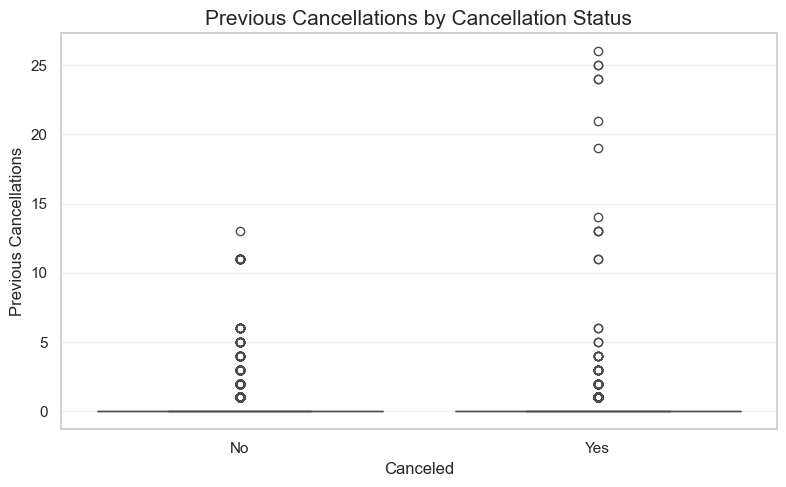

In [122]:
# Compare previous cancellations by cancellation status

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="is_canceled",
    y="previous_cancellations",
    color=PRIMARY_COLOR
)

plt.xticks([0,1],["No","Yes"])

plt.title("Previous Cancellations by Cancellation Status")
plt.xlabel("Canceled")
plt.ylabel("Previous Cancellations")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

📝 Observation

Guests with previous cancellations are more likely to cancel again.

💼 Business Insight

Previous cancellation history is a strong predictor of future cancellations.

### Total Special Requests vs Cancellation

In [123]:
# Calculate the cancellation rate by total special requests

request_cancel = (
    df.groupby("total_of_special_requests")["is_canceled"]
    .mean()
    .mul(100)
    .reset_index(name="Cancellation Rate")
)

display(request_cancel)

,total_of_special_requests,Cancellation Rate
0,0,33.264793
1,1,22.439681
2,2,21.326210
3,3,17.120623
4,4,10.625000
5,5,5.555556


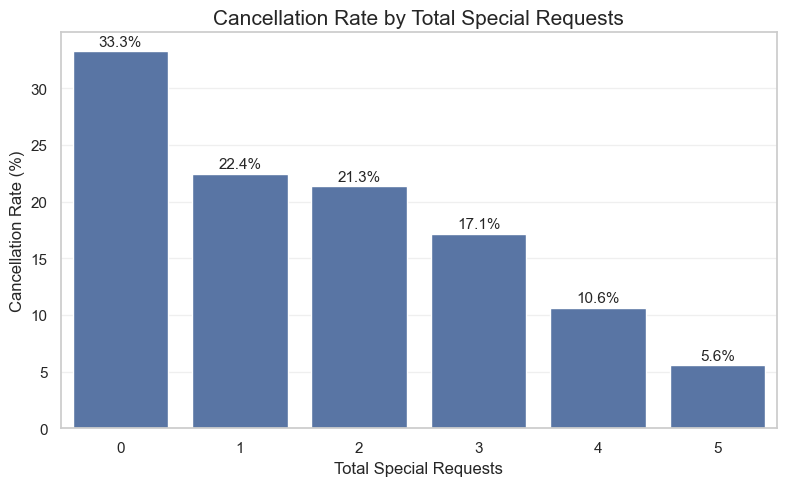

In [124]:
# Plot the cancellation rate by total special requests

plt.figure(figsize=(8,5))

sns.barplot(
    data=request_cancel,
    x="total_of_special_requests",
    y="Cancellation Rate",
    color=PRIMARY_COLOR
)

for i, value in enumerate(request_cancel["Cancellation Rate"]):
    plt.text(i, value+0.5, f"{value:.1f}%", ha="center")

plt.title("Cancellation Rate by Total Special Requests")
plt.xlabel("Total Special Requests")
plt.ylabel("Cancellation Rate (%)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

📝 Observation

Cancellation rates decrease steadily as the number of special requests increases.

💼 Business Insight

Guests making more special requests appear more committed to their stay.

### Arrival Month vs Cancellation

In [125]:
# Calculate the cancellation rate by arrival month

month_cancel = (
    df.groupby("arrival_date_month")["is_canceled"]
    .mean()
    .mul(100)
    .reindex([
        "January","February","March","April","May","June",
        "July","August","September","October","November","December"
    ])
    .reset_index(name="Cancellation Rate")
)

display(month_cancel)

,arrival_date_month,Cancellation Rate
0,January,22.143925
1,February,23.238973
2,March,24.435538
3,April,30.454603
4,May,29.270047
5,June,30.337803
6,July,31.829499
7,August,32.218466
8,September,24.562191
9,October,23.731753


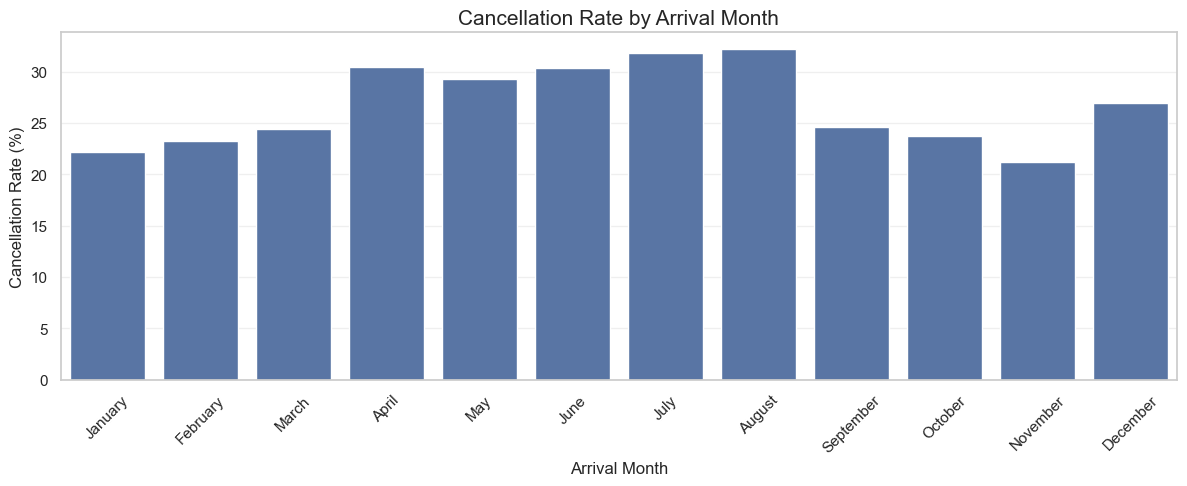

In [126]:
# Plot the cancellation rate by arrival month

plt.figure(figsize=(12,5))

sns.barplot(
    data=month_cancel,
    x="arrival_date_month",
    y="Cancellation Rate",
    color=PRIMARY_COLOR
)

plt.xticks(rotation=45)

plt.title("Cancellation Rate by Arrival Month")
plt.xlabel("Arrival Month")
plt.ylabel("Cancellation Rate (%)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

📝 Observation

Cancellation rates peak during July and August.
Lower cancellation rates are observed in January and November.

💼 Business Insight

Hotels should strengthen cancellation management strategies during peak travel seasons, especially in summer months.

## 5.4 Multivariate Analysis

### 5.4.1 Hotel Type × Deposit Type vs Cancellation

,hotel,deposit_type,Cancellation Rate
0,City Hotel,No Deposit,29.008624
1,City Hotel,Non Refund,97.159763
2,City Hotel,Refundable,66.666667
3,Resort Hotel,No Deposit,23.167687
4,Resort Hotel,Non Refund,83.937824
5,Resort Hotel,Refundable,17.391304


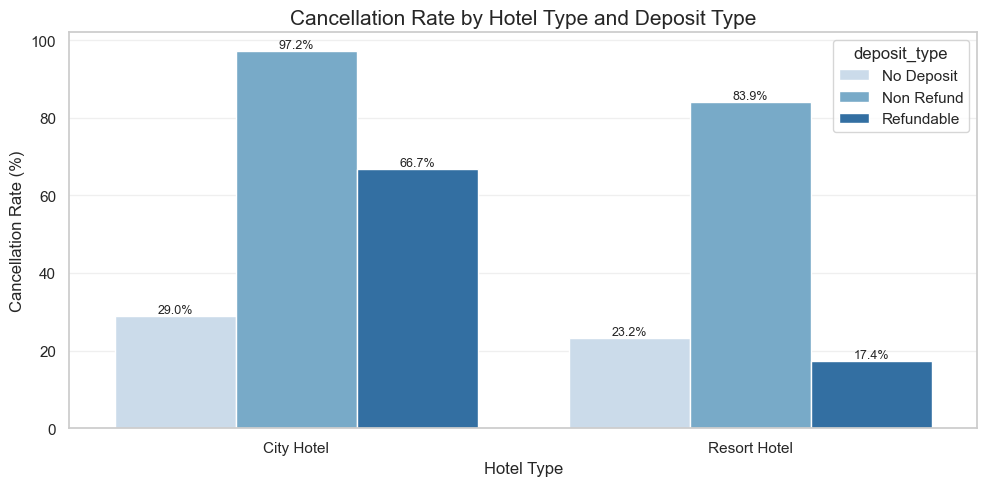

In [127]:
# Calculate the cancellation rate by hotel type and deposit type

cancel_rate = (
    df.groupby(["hotel", "deposit_type"])["is_canceled"]
    .mean()
    .mul(100)
    .reset_index(name="Cancellation Rate")
)

display(cancel_rate)

# Plot

plt.figure(figsize=(10,5))

sns.barplot(
    data=cancel_rate,
    x="hotel",
    y="Cancellation Rate",
    hue="deposit_type",
    palette="Blues"
)

for container in plt.gca().containers:
    plt.bar_label(container, fmt="%.1f%%", fontsize=9)

plt.title("Cancellation Rate by Hotel Type and Deposit Type")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate (%)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

📝 Observation

Non Refund bookings have the highest cancellation rate in both hotel types (97.2% for City Hotels and 83.9% for Resort Hotels).
Bookings without a deposit have moderate cancellation rates (29.0% for City Hotels and 23.2% for Resort Hotels).
Refundable deposits have a much lower cancellation rate in Resort Hotels (17.4%) but are relatively high in City Hotels (66.7%). However, this category contains very few bookings.

💼 Business Insight

Deposit type is one of the strongest indicators of booking cancellation. Hotels should closely monitor Non Refund bookings and evaluate booking policies to reduce cancellation risk.

### 5.4.2 Hotel Type × Market Segment vs Cancellation

,hotel,market_segment,Cancellation Rate
0,City Hotel,Aviation,19.911504
1,City Hotel,Complementary,10.735586
2,City Hotel,Corporate,11.857529
3,City Hotel,Direct,16.468039
4,City Hotel,Groups,33.867889
5,City Hotel,Offline TA/TO,17.364277
6,City Hotel,Online TA,36.118189
7,City Hotel,Undefined,100.000000
8,Resort Hotel,Complementary,16.402116
9,Resort Hotel,Corporate,12.474645


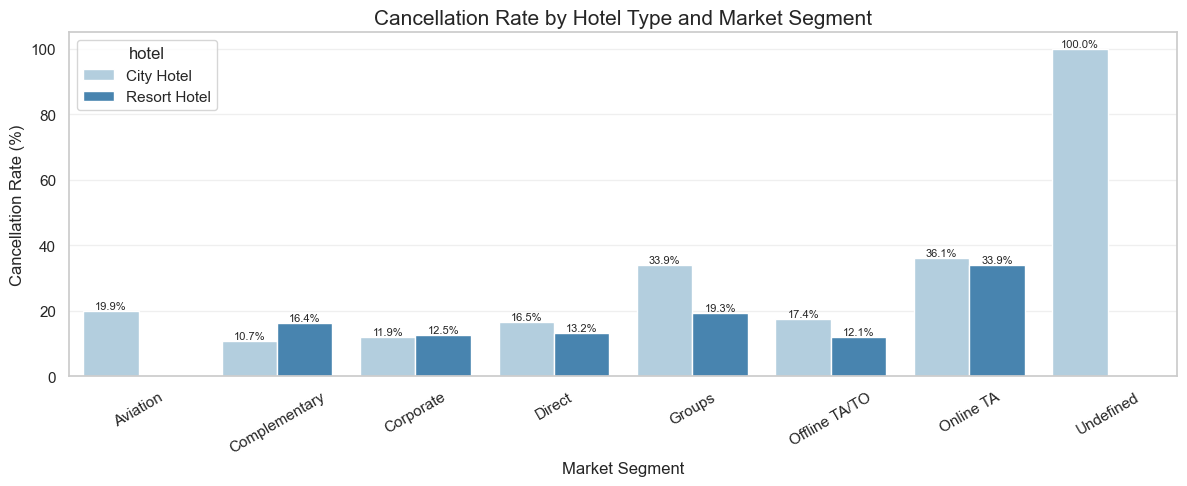

In [128]:
# Calculate the cancellation rate by hotel type and market segment

cancel_rate = (
    df.groupby(["hotel", "market_segment"])["is_canceled"]
    .mean()
    .mul(100)
    .reset_index(name="Cancellation Rate")
)

display(cancel_rate)

# Plot

plt.figure(figsize=(12,5))

sns.barplot(
    data=cancel_rate,
    x="market_segment",
    y="Cancellation Rate",
    hue="hotel",
    palette="Blues"
)

for container in plt.gca().containers:
    plt.bar_label(container, fmt="%.1f%%", fontsize=8)

plt.xticks(rotation=30)

plt.title("Cancellation Rate by Hotel Type and Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Cancellation Rate (%)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

📝 Observation

Online TA has the highest cancellation rate in both City Hotels (36.1%) and Resort Hotels (33.9%).
Group bookings show noticeably higher cancellation rates in City Hotels (33.9%) than in Resort Hotels (19.3%).
Direct, Corporate, and Offline TA/TO channels maintain relatively lower cancellation rates.
The Undefined category shows 100% cancellation but consists of only a few observations.

💼 Business Insight

Bookings coming from Online Travel Agencies represent the highest cancellation risk. Hotels should implement additional confirmation procedures or flexible pricing strategies for OTA reservations, especially in City Hotels.

### 5.4.3 Correlation with Target

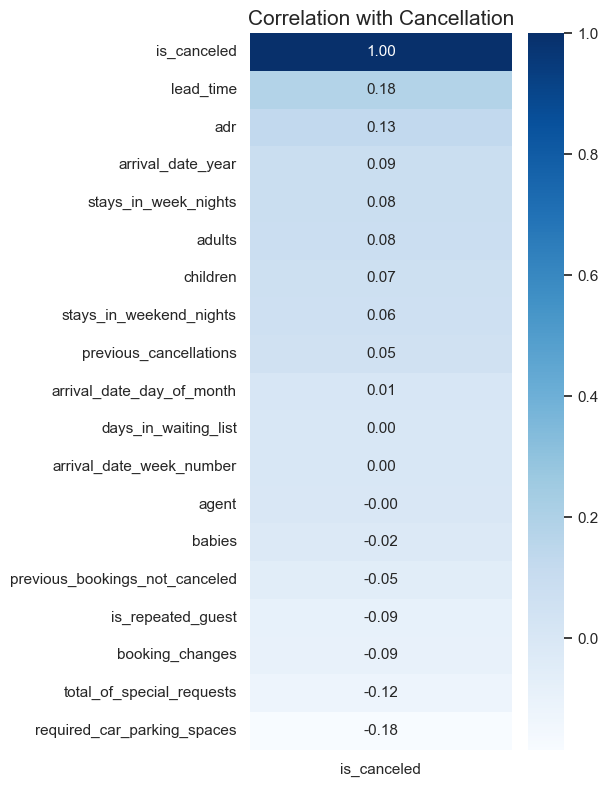

In [129]:
# Correlation of numerical features with the target (is_canceled)
corr = (
    df.select_dtypes(include="number")
      .corr()[["is_canceled"]]
      .sort_values("is_canceled", ascending=False)
)

plt.figure(figsize=(6,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation with Cancellation")

plt.tight_layout()

plt.show()

📝 Observation

Lead Time has the strongest positive correlation with cancellations.
Required Car Parking Spaces and Total Special Requests are negatively correlated with cancellations.
Most numerical features have relatively weak individual correlations with the target.

💼 Business Insight

Although no single feature strongly predicts cancellations, combining multiple numerical variables can significantly improve predictive models.

### 5.4.4 Correlation Heatmap

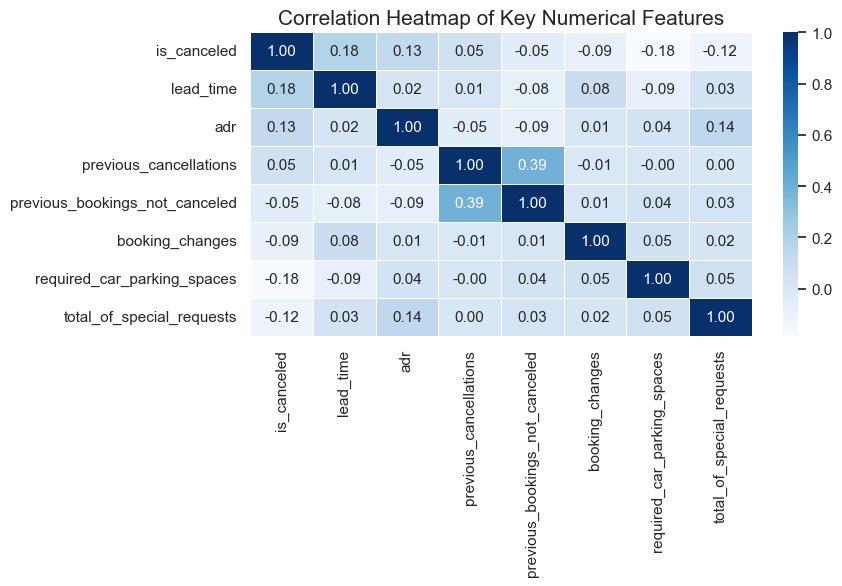

In [130]:
# Correlation matrix of key numerical features

cols = [
    "is_canceled",
    "lead_time",
    "adr",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

corr = df[cols].corr()

plt.figure(figsize=(9,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=.5
)

plt.title("Correlation Heatmap of Key Numerical Features")

plt.tight_layout()

plt.show()

📝 Observation

Most numerical features show weak correlations with each other.
Lead Time is positively related to cancellations.
Total Special Requests and Required Car Parking Spaces have negative relationships with cancellations.
No severe multicollinearity is observed among the selected features.

💼 Business Insight

The absence of strong multicollinearity suggests that these variables can be used together in machine learning models without causing major redundancy.

# 6. Key Insights

🔹Approximately 27.5% of all hotel bookings were canceled, indicating that booking cancellation is a significant business challenge.

🔹City Hotels experienced a higher cancellation rate (30.1%) than Resort Hotels (23.5%), making them more vulnerable to booking cancellations.

🔹Customers with longer lead times were more likely to cancel their reservations, suggesting that bookings made far in advance are less stable.

🔹Online Travel Agency (Online TA) bookings showed the highest cancellation rate among all major market segments, while Direct and Corporate bookings were considerably more reliable.

🔹Non Refund reservations recorded the highest cancellation rates in both hotel types, highlighting a strong relationship between deposit policy and booking behavior.

🔹Repeated guests canceled their reservations far less frequently than first-time guests, indicating the positive impact of customer loyalty.

🔹Guests who submitted more special requests had progressively lower cancellation rates, suggesting that engaged customers are more committed to completing their stays.

🔹Cancellation rates were generally higher during the summer season, particularly in July and August, reflecting increased booking uncertainty during peak travel periods.

🔹The correlation analysis showed that Lead Time has the strongest positive relationship with cancellations, while Required Car Parking Spaces and Total Special Requests are negatively related to cancellation behavior.

🔹No single numerical feature strongly explains booking cancellations, indicating that cancellation behavior is influenced by a combination of customer characteristics, booking details, and reservation policies.

==========================================================================================================================

حوالي 27.5% من إجمالي الحجوزات تم إلغاؤها، مما يشير إلى أن إلغاء الحجوزات يمثل تحديًا رئيسيًا للفنادق.

فنادق المدينة (City Hotels) سجلت معدل إلغاء أعلى من فنادق المنتجعات (Resort Hotels)، مما يجعلها أكثر عرضة لخسارة الحجوزات.

كلما زادت مدة الحجز المسبق (Lead Time)، زادت احتمالية إلغاء الحجز، مما يدل على أن الحجوزات المبكرة تكون أقل استقرارًا.

الحجوزات القادمة من Online Travel Agencies (Online TA) حققت أعلى معدلات إلغاء مقارنة بباقي قنوات الحجز.

نوع Non Refund سجل أعلى معدلات إلغاء في كلا نوعي الفنادق، مما يوضح وجود علاقة قوية بين سياسة الدفع وسلوك العملاء.

العملاء المتكررون (Repeated Guests) كانوا أقل عرضة لإلغاء حجوزاتهم مقارنة بالعملاء الجدد، مما يعكس أثر ولاء العملاء.

كلما زاد عدد الطلبات الخاصة (Special Requests)، انخفض معدل الإلغاء، مما يشير إلى أن العملاء الأكثر تفاعلًا يكونون أكثر التزامًا بالحجز.

ارتفعت معدلات الإلغاء خلال موسم الصيف، خاصة في شهري يوليو وأغسطس، وهو ما يعكس زيادة عدم استقرار الحجوزات في مواسم الذروة.

أظهر تحليل الارتباط أن Lead Time هو أكثر المتغيرات الرقمية ارتباطًا بزيادة الإلغاء، بينما ارتبط كل من Required Car Parking Spaces و Total Special Requests بانخفاض احتمالية الإلغاء.

لا يوجد متغير واحد قادر على تفسير الإلغاء بشكل كامل، وإنما يعتمد سلوك الإلغاء على مجموعة من خصائص العميل والحجز وسياسات الفندق.

# 7. Business Recommendations

🔹Monitor reservations with long lead times more closely by sending reminder emails or offering reconfirmation before the arrival date.

🔹Strengthen booking management for Online TA reservations through confirmation campaigns or optimized cancellation policies to reduce booking losses.

🔹Encourage direct bookings by offering exclusive discounts or loyalty benefits, as these reservations show lower cancellation rates than OTA bookings.

🔹Expand customer loyalty programs to increase the number of repeated guests, who demonstrate significantly lower cancellation behavior.

🔹Review and optimize deposit policies, particularly for booking channels and customer groups with historically high cancellation rates.

🔹Provide personalized services and encourage guests to submit special requests, as higher customer engagement is associated with lower cancellation rates.

🔹Increase operational preparedness during peak travel months, especially July and August, when cancellation rates tend to be higher.

🔹Incorporate the identified key features—such as Lead Time, Deposit Type, Market Segment, Special Requests, and Repeated Guest Status—into the upcoming machine learning model to improve cancellation prediction accuracy.Monitor reservations with long lead times more closely by sending reminder emails or offering reconfirmation before the arrival date.

🔹Strengthen booking management for Online TA reservations through confirmation campaigns or optimized cancellation policies to reduce booking losses.

🔹Encourage direct bookings by offering exclusive discounts or loyalty benefits, as these reservations show lower cancellation rates than OTA bookings.

🔹Expand customer loyalty programs to increase the number of repeated guests, who demonstrate significantly lower cancellation behavior.

🔹Review and optimize deposit policies, particularly for booking channels and customer groups with historically high cancellation rates.

🔹Provide personalized services and encourage guests to submit special requests, as higher customer engagement is associated with lower cancellation rates.

🔹Increase operational preparedness during peak travel months, especially July and August, when cancellation rates tend to be higher.

🔹Incorporate the identified key features—such as Lead Time, Deposit Type, Market Segment, Special Requests, and Repeated Guest Status—into the upcoming machine learning model to improve cancellation prediction accuracy.

==========================================================================================================================

متابعة الحجوزات ذات مدة الحجز المسبق الطويلة من خلال إرسال رسائل تذكير أو طلب تأكيد الحجز قبل موعد الوصول.

تحسين إدارة الحجوزات القادمة من منصات الحجز الإلكترونية (Online TA)، لأنها تمثل أعلى نسبة من الإلغاءات.

تشجيع الحجز المباشر (Direct Booking) عبر تقديم مزايا أو خصومات حصرية، نظرًا لانخفاض معدل الإلغاء مقارنة بالحجوزات القادمة من الوسطاء.

الاستثمار في برامج ولاء العملاء لزيادة عدد العملاء المتكررين، حيث أثبتت النتائج أنهم أقل عرضة لإلغاء الحجوزات.

مراجعة سياسات العربون (Deposit Policies) بما يحقق توازنًا بين مرونة الحجز وتقليل مخاطر الإلغاء.

الاهتمام بتقديم خدمات مخصصة وتشجيع العملاء على إضافة طلبات خاصة أثناء الحجز، لأن ذلك يرتبط بانخفاض معدلات الإلغاء.

الاستعداد بشكل أكبر خلال مواسم الذروة، خاصة في شهري يوليو وأغسطس، من خلال خطط تشغيل وإدارة أكثر مرونة للتعامل مع ارتفاع معدلات الإلغاء.

عند بناء نموذج التعلم الآلي (Machine Learning)، ينبغي التركيز على المتغيرات الأكثر تأثيرًا مثل Lead Time، Deposit Type، Market Segment، Total Special Requests، وRepeated Guest Status، لأنها أثبتت أهميتها في تفسير سلوك الإلغاء.

# 8. Save Clean Dataset

In [131]:
# 8. Save Clean Dataset

df.to_csv("D:\datascience222\youssef samy youssef (final project)\Hotel-Booking-Cancellation\data\hotel_bookings_cleaned.csv", index=False)

print("✅ Cleaned dataset saved successfully.")

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\LOQ\AppData\Local\Temp\ipykernel_452\4110443639.py:3: SyntaxWarning: invalid escape sequence '\d'
  df.to_csv("D:\datascience222\youssef samy youssef (final project)\Hotel-Booking-Cancellation\data\hotel_bookings_cleaned.csv", index=False)


✅ Cleaned dataset saved successfully.
